# humidity

In [108]:
import pandas as pd

In [109]:
df_district = pd.read_csv('../1980-2024-dataset/Rangamati_historical_weather_1980_2024.csv')

df_district = df_district.drop('district', axis =1 )

desired_colmn = ['day', 'month', 'year', 'humidity']
df_district = df_district[desired_colmn]

df_district = df_district.dropna()

df_district.head()

,day,month,year,humidity
6,7,1,1980,52.9
386,21,1,1981,80.0
731,1,1,1982,82.5
732,2,1,1982,70.3
733,3,1,1982,8.2


Date range: 2014-01-01 to 2024-12-31


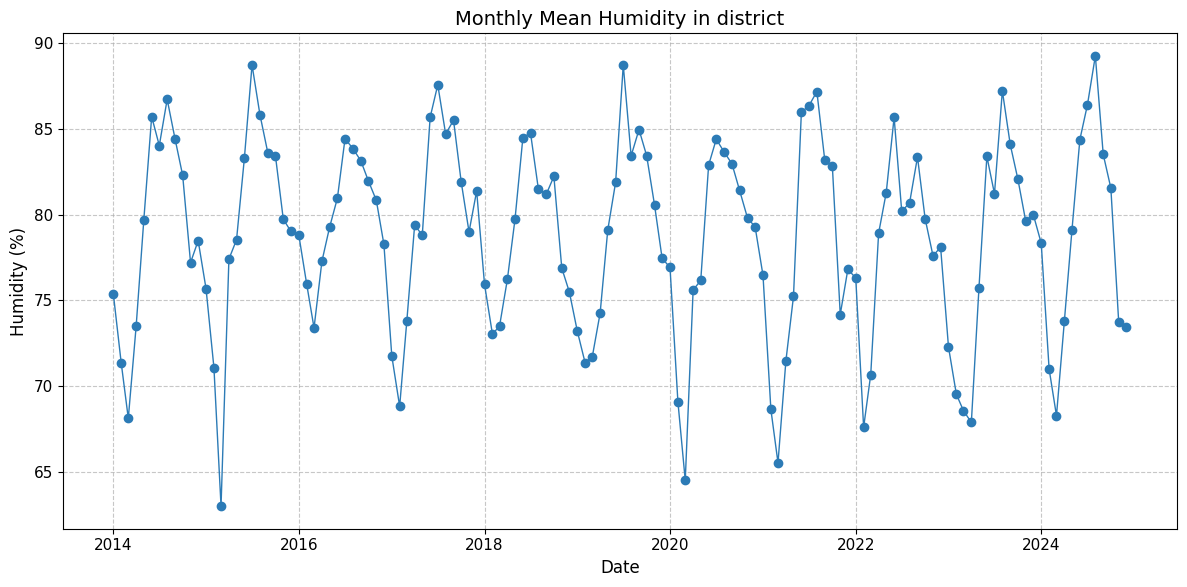

In [110]:
import matplotlib.pyplot as plt

if 'date' not in df_district.columns:
    df_district['date'] = pd.to_datetime(df_district[['year', 'month', 'day']])

# # show date range
# min_date = df_district['date'].min()
# max_date = df_district['date'].max()
# print(f"Date range: {min_date.date()} to {max_date.date()}")

# 2010-2024 dile 83% r2 lightgbm
# 2014- 2024 dile 82% R2
# 2018-2024 dile 52% R2 xgboost

# filter data for custom date range: 2020 to 2024
df_district = df_district[
    (df_district['date'] >= '2014-01-01') & (df_district['date'] <= '2024-12-31')
]
custom_range_df = df_district.copy()

# show date range
min_date = custom_range_df['date'].min()
max_date = custom_range_df['date'].max()

df_district['date'] = pd.to_datetime(df_district['date'])
df_district.set_index('date', inplace=True)

df_monthly_hum = df_district['humidity'].resample('MS').mean()
# Fill missing gaps using linear interpolation (common for weather data)
df_monthly_hum = df_monthly_hum.interpolate(method='linear')

print(f"Date range: {min_date.date()} to {max_date.date()}")

# --- Plotting ---
plt.figure(figsize=(12, 6))
plt.plot(df_monthly_hum, marker='o', linestyle='-', color='#2c7bb6', linewidth=1)
plt.title('Monthly Mean Humidity in district', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Humidity (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) 

# pchip: Piecewise Cubic Hermite Interpolating Polynomial

df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_hum.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]



In [112]:
df_monthly_hum.head()

,date,humidity
0,2014-01-01,75.390323
1,2014-02-01,71.367857
2,2014-03-01,68.119355
3,2014-04-01,73.510000
4,2014-05-01,79.670968


In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit

FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['humidity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)


## RF hum

In [114]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6, 
    min_samples_split=2,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1,
    max_features= 1.0
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rf_r2_f  = r2_score(y_test, y_pred)
rf_mse_f = mean_squared_error(y_test, y_pred)
rf_rmse_f = np.sqrt(rf_mse_f)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

rf_acc_05 = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10 = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20 = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30 = tolerance_accuracy(y_test.values, y_pred, 3.0)

print("=== Random Forest + Fourier – Humidity Prediction (Test) ===")
print(f"R²          : {rf_r2_f:.4f}")
print(f"RMSE        : {rf_rmse_f:.3f} °C")
print(f"MSE         : {rf_mse_f:.4f}")
print("Accuracy (± tolerance):")
print(f"  ±0.5 °C : {rf_acc_05 * 100:5.2f}%")
print(f"  ±1.0 °C : {rf_acc_10 * 100:5.2f}%")
print(f"  ±2.0 °C : {rf_acc_20 * 100:5.2f}%")
print(f"  ±3.0 °C : {rf_acc_30 * 100:5.2f}%")

# ------------------------------------------------------------------
# 9. 5-fold CV (R²)
# ------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

# 2. Run cross-validation using the tscv object
rf_cv_r2 = cross_val_score(rf, X, y, cv=tscv, scoring='r2', n_jobs=-1)

print("\n=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===")
print(f"Mean R² : {rf_cv_r2.mean():.4f}  (±{rf_cv_r2.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest + Fourier – Humidity Prediction (Test) ===
R²          : 0.7617
RMSE        : 2.518 °C
MSE         : 6.3396
Accuracy (± tolerance):
  ±0.5 °C : 14.81%
  ±1.0 °C : 37.04%
  ±2.0 °C : 51.85%
  ±3.0 °C : 74.07%

=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===
Mean R² : 0.7044  (±0.0970)
Scores  : [0.5217 0.6895 0.7748 0.7526 0.7833]

=== Feature Importances (Top 10) ===
 feature  importance
   sin_1    0.701840
   cos_1    0.197130
   sin_2    0.044220
year_val    0.018596
   cos_3    0.013223
   cos_2    0.013135
   sin_3    0.011856


## XGBoost hum

In [115]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = xgb_model.predict(X_test)

xgboost_r2_f  = r2_score(y_test, y_pred)            # averaged R^2 for multioutput
xgboost_mse_f = mean_squared_error(y_test, y_pred)  # averaged MSE
xgboost_rmse_f = np.sqrt(xgboost_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    # returns fraction (0..1) of predictions within tol across all targets
    return ((np.abs(y_true - y_hat) <= tol).mean())

xgboost_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
xgboost_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
xgboost_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
xgboost_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== XGBoost Regression Metrics (Test) ====")
print(f"xgboost_R^2  : {xgboost_r2_f:.4f}")
print(f"xgboost_MSE  : {xgboost_mse_f:.4f}")
print(f"xgboost_RMSE : {xgboost_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {xgboost_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {xgboost_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {xgboost_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {xgboost_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)

xgb_cv_r2 = cross_val_score(xgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean xgboost_R^2 : {xgb_cv_r2.mean():.4f}  |  Std : {xgb_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---
# MultiOutputRegressor stores estimators_ after fit


fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.head(10).to_string(index=False))

==== XGBoost Regression Metrics (Test) ====
xgboost_R^2  : 0.7623
xgboost_MSE  : 6.3255
xgboost_RMSE : 2.5151
Accuracy (|error| ≤ tolerance):
  ±0.5°C :  7.41%
  ±1.0°C : 25.93%
  ±2.0°C : 55.56%
  ±3.0°C : 74.07%

==== 5-Fold CV R^2 ====
Mean xgboost_R^2 : 0.5939  |  Std : 0.1299

==== Top Feature Importances ====
 feature  importance
   sin_1    0.330333
   sin_2    0.224920
   cos_1    0.197089
   cos_2    0.083801
   cos_3    0.073153
   sin_3    0.057589
year_val    0.033115


## light gbm hum

In [116]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor


# --- 4) Train MultiOutput LightGBM ---
import lightgbm as lgb

# Optimized for Seasonal Shape extraction on N=132
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = lgb_model.predict(X_test)

lgb_r2_f  = r2_score(y_test, y_pred)
lgb_mse_f = mean_squared_error(y_test, y_pred)
lgb_rmse_f = np.sqrt(lgb_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

lgb_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
lgb_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
lgb_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
lgb_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== LightGBM Regression Metrics (Test) ====")
print(f"LGB_R^2  : {lgb_r2_f:.4f}")
print(f"LGB_MSE  : {lgb_mse_f:.4f}")
print(f"LGB_RMSE : {lgb_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {lgb_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {lgb_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {lgb_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {lgb_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
lgb_cv_r2 = cross_val_score(lgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean LGB_R^2 : {lgb_cv_r2.mean():.4f}  |  Std : {lgb_cv_r2.std():.4f}")



fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== LightGBM Regression Metrics (Test) ====
LGB_R^2  : 0.7448
LGB_MSE  : 6.7894
LGB_RMSE : 2.6056
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 11.11%
  ±1.0°C : 29.63%
  ±2.0°C : 44.44%
  ±3.0°C : 66.67%

==== 5-Fold CV R^2 ====
Mean LGB_R^2 : 0.7118  |  Std : 0.0875

==== Top Feature Importances ====
 feature   importance
   sin_1 59168.617675
   cos_1 25290.456364
year_val 13178.760358
   sin_2 13150.874384
   sin_3  9287.145415
   cos_3  6331.959545
   cos_2  3549.501578


## cat boost hum

In [117]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor

# --- 4) Train MultiOutput LightGBM ---
cat_model = CatBoostRegressor(
    iterations=1500,           # Increased iterations with a lower learning rate
    learning_rate=0.01,        # "Crawl" toward the seasonal trend
    depth=4,                   # Shallower trees for better generalization on small N=132
    l2_leaf_reg=10,            # Higher L2 regularization to smooth the seasonal curve
    
    bootstrap_type='Bayesian',
    bagging_temperature=0.5,   # Reduced slightly for more stable bagging
    random_strength=2,         # Adds randomness to scoring splits, preventing overfitting
    
    loss_function='RMSE',      # Standard for regression; 'Huber' is also an option if data is noisy
    od_type='Iter',            # Overfitting detector
    od_wait=50,                # Stop early if the trend isn't improving
    
    random_seed=42,
    verbose=0
)


cat_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = cat_model.predict(X_test)

cat_r2_f  = r2_score(y_test, y_pred)
cat_mse_f = mean_squared_error(y_test, y_pred)
cat_rmse_f = np.sqrt(cat_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

cat_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
cat_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
cat_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
cat_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== CatBoost Regression Metrics (Test) ====")
print(f"CatBoost_R^2  : {cat_r2_f:.4f}")
print(f"CatBoost_MSE  : {cat_mse_f:.4f}")
print(f"CatBoost_RMSE : {cat_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {cat_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {cat_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {cat_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {cat_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
cat_cv_r2 = cross_val_score(cat_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean CAT_R^2 : {cat_cv_r2.mean():.4f}  |  Std : {cat_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---

fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": cat_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== CatBoost Regression Metrics (Test) ====
CatBoost_R^2  : 0.7510
CatBoost_MSE  : 6.6258
CatBoost_RMSE : 2.5741
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 14.81%
  ±1.0°C : 33.33%
  ±2.0°C : 40.74%
  ±3.0°C : 70.37%

==== 5-Fold CV R^2 ====
Mean CAT_R^2 : 0.6965  |  Std : 0.0661

==== Top Feature Importances ====
 feature  importance
   sin_1   47.180050
   cos_1   17.575777
   sin_2   10.404236
year_val    7.305635
   sin_3    6.018552
   cos_2    5.861564
   cos_3    5.654186


## comparision humidity

In [118]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_f, xgboost_r2_f, lgb_r2_f, cat_r2_f],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2.mean(), xgb_cv_r2.mean(), lgb_cv_r2.mean(), cat_cv_r2.mean()],
    "MSE": [rf_mse_f, xgboost_mse_f, lgb_mse_f, cat_mse_f],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_f, xgboost_rmse_f, lgb_rmse_f, cat_rmse_f],  # Replace with actual RMSE values from each model
    "Acc ±0.5°C (%)": [rf_acc_05*100, xgboost_acc_05*100, lgb_acc_05*100, cat_acc_05*100],  # Replace with actual accuracy values
    "Acc ±1.0°C (%)": [rf_acc_10*100, xgboost_acc_10*100, lgb_acc_10*100, cat_acc_10*100],
    "Acc ±2.0°C (%)": [rf_acc_20*100, xgboost_acc_20*100, lgb_acc_20*100, cat_acc_20*100],
    "Acc ±3.0°C (%)": [rf_acc_30*100, xgboost_acc_30*100, lgb_acc_30*100, cat_acc_30*100],
})
print("\n==== Model Performance Comparison ====")
print(model_performance.to_string(index=False))



==== Model Performance Comparison ====
        Model      R^2    CV R2      MSE     RMSE  Acc ±0.5°C (%)  Acc ±1.0°C (%)  Acc ±2.0°C (%)  Acc ±3.0°C (%)
Random Forest 0.761748 0.704385 6.339647 2.517866       14.814815       37.037037       51.851852       74.074074
      XGBoost 0.762280 0.593911 6.325505 2.515056        7.407407       25.925926       55.555556       74.074074
     LightGBM 0.744847 0.711766 6.789361 2.605640       11.111111       29.629630       44.444444       66.666667
     CatBoost 0.750996 0.696502 6.625755 2.574054       14.814815       33.333333       40.740741       70.370370


In [119]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Acc ±1.0°C (%)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Acc ±1.0°C (%)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results = select_best_model_journal(model_performance)
print(journal_results[['Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

           Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
0  Random Forest  0.761748  0.704385  0.057363         0.934620        Robust
3       CatBoost  0.750996  0.696502  0.054494         0.610548        Robust
2       LightGBM  0.744847  0.711766  0.033081         0.483333        Robust
1        XGBoost  0.762280  0.593911  0.168369         0.450000  Overfit Risk


## predicting with best model for two years humidity

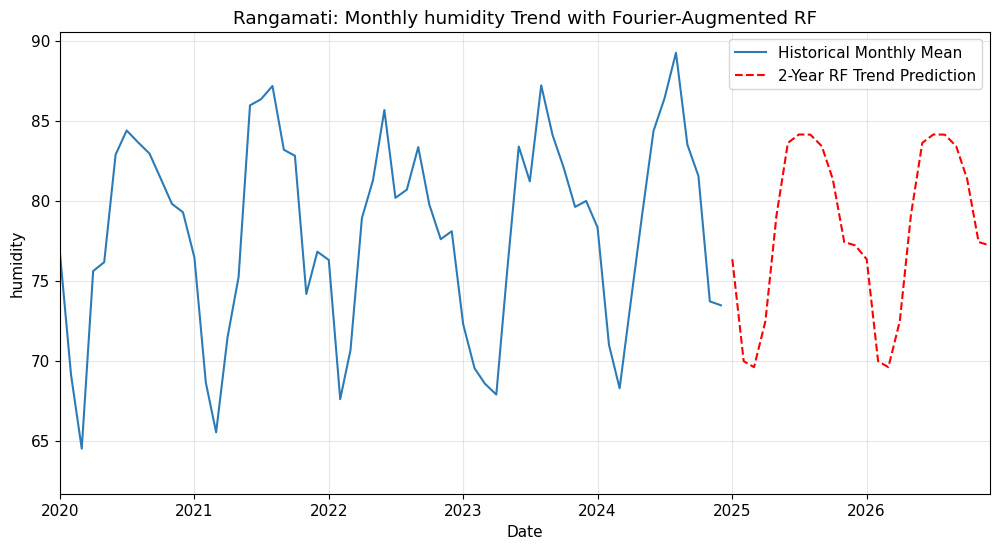

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_hum.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['humidity']

# 4. Train Random Forest [cite: 145, 146]
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6, 
    min_samples_split=2,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1,
    max_features= 1.0
)
rf.fit(X_train, y_train)

# 5. Predict 2 Years Future (24 months)
last_date = df_features['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_df = pd.DataFrame({'date': future_dates})
future_df['year_val'] = future_df['date'].dt.year
future_df = add_fourier_features(future_df)

predictions_hum = rf.predict(future_df[FEATURES])


# 6. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_features['date'], y, label='Historical Monthly Mean', color='#2c7bb6') # [cite: 80]
plt.plot(future_dates, predictions_hum, label='2-Year RF Trend Prediction', linestyle='--', color='red')
plt.title('Rangamati: Monthly humidity Trend with Fourier-Augmented RF')
plt.xlabel('Date')
plt.ylabel('humidity')
plt.legend()
plt.grid(True, alpha=0.3)
# Set the start date to Jan 1st, 2023
plt.xlim(pd.Timestamp('2020-01-01'), future_dates.max())
plt.show()

<>:20: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:24: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:20: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:24: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_9552\2654542030.py:20: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')
C:\Users\User\AppData\Local\Temp\ipykernel_9552\2654542030.py:24: SyntaxWarning: "\p" is an

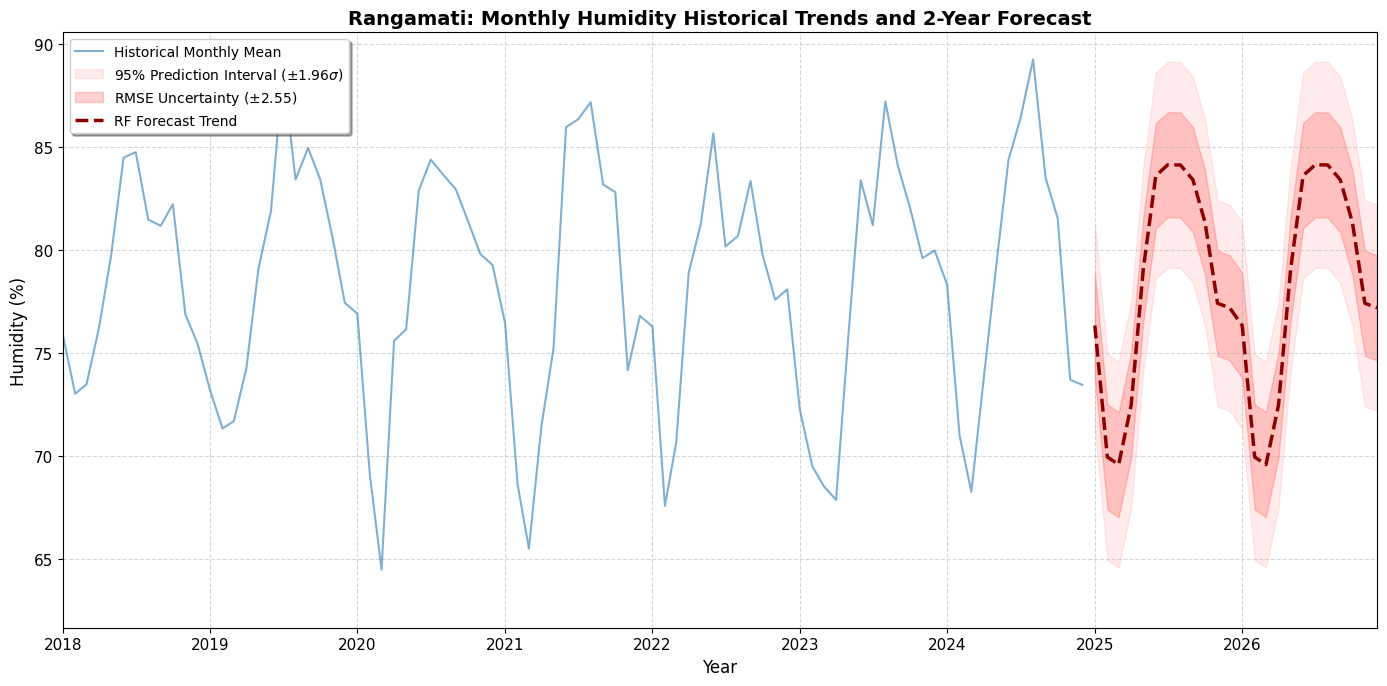

In [121]:
# 5. Predict 2 Years Future with Empirical Validation
mean_preds = rf.predict(future_df[FEATURES])

best_model_rmse = 2.548683 
upper_95 = mean_preds + (1.96 * best_model_rmse)
lower_95 = mean_preds - (1.96 * best_model_rmse)
upper_68 = mean_preds + best_model_rmse
lower_68 = mean_preds - best_model_rmse

# 2. Setup the Plot
plt.figure(figsize=(14, 7))

# 3. Plot Historical Data (The Context)
# Ensure df_features['date'] is in datetime format
plt.plot(df_features['date'], y, label='Historical Monthly Mean', 
         color='#2c7bb6', alpha=0.6, linewidth=1.5)

# 4. Plot the 95% Confidence Interval (The Outer Cloud)
plt.fill_between(future_dates, lower_95, upper_95, 
                 color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')

# 5. Plot the 68% Confidence Interval (The RMSE Cloud)
plt.fill_between(future_dates, lower_68, upper_68, 
                 color='red', alpha=0.18, label=f'RMSE Uncertainty ($\pm${best_model_rmse:.2f})')

# 6. Plot the Future Prediction Mean (The Trend)
plt.plot(future_dates, mean_preds, label='RF Forecast Trend', 
         linestyle='--', color='darkred', lw=2.5)

# 7. Journal Formatting & Aesthetics
plt.title('Rangamati: Monthly Humidity Historical Trends and 2-Year Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Humidity (%)', fontsize=12)

# Set the x-axis to start slightly before the forecast for better perspective
# Adjust '2018-01-01' to whatever date makes your historical trend visible
plt.xlim(pd.Timestamp('2018-01-01'), future_dates.max()) 

plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: Tight layout to prevent label clipping
plt.tight_layout()

plt.show()

In [122]:
# create the dataframe of the predicted values of 2025 and 2026
df_predictions_humidity = pd.DataFrame({
    'date': future_dates,
    'predicted_humidity': predictions_hum
})


In [123]:
df_predictions_humidity

,date,predicted_humidity
0,2025-01-01,76.342814
1,2025-02-01,69.969725
2,2025-03-01,69.597921
3,2025-04-01,72.480554
4,2025-05-01,79.071955
5,2025-06-01,83.611884
6,2025-07-01,84.136935
7,2025-08-01,84.127007
8,2025-09-01,83.408901
9,2025-10-01,81.341130


# temperature

In [124]:
import pandas as pd

In [125]:
df_district = pd.read_csv('../1980-2024-dataset/Bagerhat_historical_weather_1980_2024.csv')

df_district = df_district.drop('district', axis =1 )

desired_colmn = ['day', 'month', 'year', 'temperature(degree C)']
df_district = df_district[desired_colmn]

df_district = df_district.dropna()

df_district.head()

,day,month,year,temperature(degree C)
0,1,1,1980,21.7
1,2,1,1980,20.8
2,3,1,1980,23.0
3,4,1,1980,22.3
4,5,1,1980,22.1


Date range: 2014-01-01 to 2024-12-31


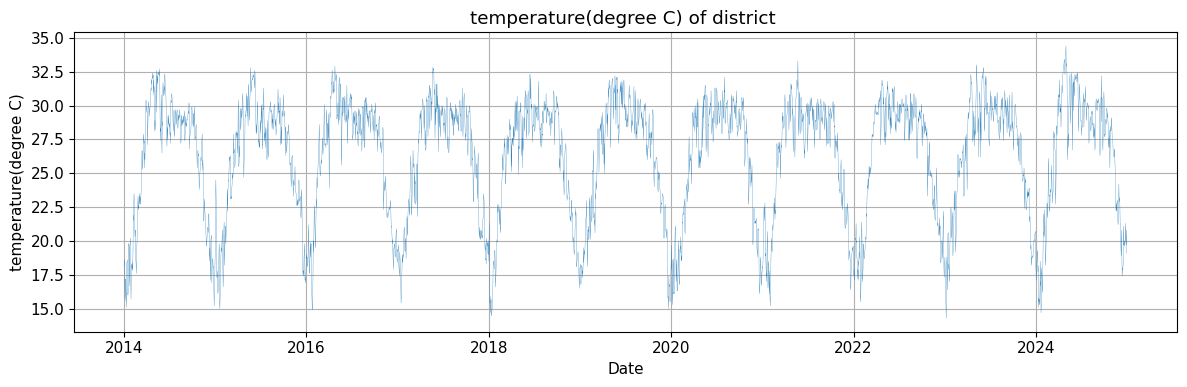

In [126]:
import matplotlib.pyplot as plt

if 'date' not in df_district.columns:
    df_district['date'] = pd.to_datetime(df_district[['year', 'month', 'day']])

# # show date range
# min_date = df_district['date'].min()
# max_date = df_district['date'].max()
# print(f"Date range: {min_date.date()} to {max_date.date()}")


# 1980-2024 dile 92% R2 xgboost
# 2010-2024 dile 96.7% r2 rf
# 2014/2024 filr 95% r2 xgboost
# filter data for custom date range: 2020 to 2024
df_district = df_district[
    (df_district['date'] >= '2014-01-01') & (df_district['date'] <= '2024-12-31')
]
custom_range_df = df_district.copy()

# show date range
min_date = custom_range_df['date'].min()
max_date = custom_range_df['date'].max()
print(f"Date range: {min_date.date()} to {max_date.date()}")

# plot daily temperature time series
plt.figure(figsize=(12, 4))
plt.plot(df_district['date'], df_district['temperature(degree C)'], linewidth=0.2)
plt.xlabel('Date')
plt.ylabel('temperature(degree C)')
plt.title('temperature(degree C) of district ')
plt.grid(True)
plt.tight_layout()
plt.show()

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna() # Fill missing gaps using linear interpolation (common for weather data)

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_temp.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]



In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score

FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['temperature(degree C)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)


## RF temp

In [129]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6, 
    min_samples_split=2,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1,
    max_features= 1.0
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rf_r2_f  = r2_score(y_test, y_pred)
rf_mse_f = mean_squared_error(y_test, y_pred)
rf_rmse_f = np.sqrt(rf_mse_f)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

rf_acc_05 = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10 = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20 = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30 = tolerance_accuracy(y_test.values, y_pred, 3.0)

print("=== Random Forest + Fourier – Humidity Prediction (Test) ===")
print(f"R²          : {rf_r2_f:.4f}")
print(f"RMSE        : {rf_rmse_f:.3f} °C")
print(f"MSE         : {rf_mse_f:.4f}")
print("Accuracy (± tolerance):")
print(f"  ±0.5 °C : {rf_acc_05 * 100:5.2f}%")
print(f"  ±1.0 °C : {rf_acc_10 * 100:5.2f}%")
print(f"  ±2.0 °C : {rf_acc_20 * 100:5.2f}%")
print(f"  ±3.0 °C : {rf_acc_30 * 100:5.2f}%")

# ------------------------------------------------------------------
# 9. 5-fold CV (R²)
# ------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

# 2. Run cross-validation using the tscv object
rf_cv_r2 = cross_val_score(rf, X, y, cv=tscv, scoring='r2', n_jobs=-1)

print("\n=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===")
print(f"Mean R² : {rf_cv_r2.mean():.4f}  (±{rf_cv_r2.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest + Fourier – Humidity Prediction (Test) ===
R²          : 0.9271
RMSE        : 1.092 °C
MSE         : 1.1918
Accuracy (± tolerance):
  ±0.5 °C : 29.63%
  ±1.0 °C : 59.26%
  ±2.0 °C : 96.30%
  ±3.0 °C : 100.00%

=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===
Mean R² : 0.7686  (±0.2054)
Scores  : [0.3789 0.7561 0.8502 0.9485 0.9094]

=== Feature Importances (Top 10) ===
 feature  importance
   cos_1    0.752302
   sin_1    0.124742
   sin_2    0.086626
   cos_2    0.013424
   sin_3    0.011631
   cos_3    0.007490
year_val    0.003785


## XGBoost temp

In [130]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = xgb_model.predict(X_test)

xgboost_r2_f  = r2_score(y_test, y_pred)            # averaged R^2 for multioutput
xgboost_mse_f = mean_squared_error(y_test, y_pred)  # averaged MSE
xgboost_rmse_f = np.sqrt(xgboost_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    # returns fraction (0..1) of predictions within tol across all targets
    return ((np.abs(y_true - y_hat) <= tol).mean())

xgboost_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
xgboost_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
xgboost_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
xgboost_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== XGBoost Regression Metrics (Test) ====")
print(f"xgboost_R^2  : {xgboost_r2_f:.4f}")
print(f"xgboost_MSE  : {xgboost_mse_f:.4f}")
print(f"xgboost_RMSE : {xgboost_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {xgboost_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {xgboost_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {xgboost_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {xgboost_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)

xgb_cv_r2 = cross_val_score(xgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean xgboost_R^2 : {xgb_cv_r2.mean():.4f}  |  Std : {xgb_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---
# MultiOutputRegressor stores estimators_ after fit


fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.head(10).to_string(index=False))

==== XGBoost Regression Metrics (Test) ====
xgboost_R^2  : 0.9601
xgboost_MSE  : 0.6530
xgboost_RMSE : 0.8081
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 48.15%
  ±1.0°C : 74.07%
  ±2.0°C : 100.00%
  ±3.0°C : 100.00%

==== 5-Fold CV R^2 ====
Mean xgboost_R^2 : 0.9606  |  Std : 0.0086

==== Top Feature Importances ====
 feature  importance
   cos_1    0.534790
   sin_2    0.176132
   sin_1    0.138252
   sin_3    0.085021
   cos_3    0.036047
   cos_2    0.024610
year_val    0.005147


## light gbm temp

In [131]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor


# --- 4) Train MultiOutput LightGBM ---
import lightgbm as lgb

# Optimized for Seasonal Shape extraction on N=132
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = lgb_model.predict(X_test)

lgb_r2_f  = r2_score(y_test, y_pred)
lgb_mse_f = mean_squared_error(y_test, y_pred)
lgb_rmse_f = np.sqrt(lgb_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

lgb_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
lgb_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
lgb_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
lgb_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== LightGBM Regression Metrics (Test) ====")
print(f"LGB_R^2  : {lgb_r2_f:.4f}")
print(f"LGB_MSE  : {lgb_mse_f:.4f}")
print(f"LGB_RMSE : {lgb_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {lgb_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {lgb_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {lgb_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {lgb_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
lgb_cv_r2 = cross_val_score(lgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean LGB_R^2 : {lgb_cv_r2.mean():.4f}  |  Std : {lgb_cv_r2.std():.4f}")



fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== LightGBM Regression Metrics (Test) ====
LGB_R^2  : 0.9584
LGB_MSE  : 0.6799
LGB_RMSE : 0.8245
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 48.15%
  ±1.0°C : 74.07%
  ±2.0°C : 100.00%
  ±3.0°C : 100.00%

==== 5-Fold CV R^2 ====
Mean LGB_R^2 : 0.9620  |  Std : 0.0112

==== Top Feature Importances ====
 feature   importance
   cos_1 30449.602225
   sin_1 11932.161401
   sin_2  5965.043584
   sin_3  4640.441839
   cos_2  3521.615519
   cos_3  2170.755985
year_val   903.412942


## cat boost temp

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor

# --- 4) Train MultiOutput LightGBM ---
cat_model = CatBoostRegressor(
    iterations=1500,           # Increased iterations with a lower learning rate
    learning_rate=0.01,        # "Crawl" toward the seasonal trend
    depth=4,                   # Shallower trees for better generalization on small N=132
    l2_leaf_reg=10,            # Higher L2 regularization to smooth the seasonal curve
    
    bootstrap_type='Bayesian',
    bagging_temperature=0.5,   # Reduced slightly for more stable bagging
    random_strength=2,         # Adds randomness to scoring splits, preventing overfitting
    
    loss_function='RMSE',      # Standard for regression; 'Huber' is also an option if data is noisy
    od_type='Iter',            # Overfitting detector
    od_wait=50,                # Stop early if the trend isn't improving
    
    random_seed=42,
    verbose=0
)


cat_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = cat_model.predict(X_test)

cat_r2_f  = r2_score(y_test, y_pred)
cat_mse_f = mean_squared_error(y_test, y_pred)
cat_rmse_f = np.sqrt(cat_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

cat_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
cat_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
cat_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
cat_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== CatBoost Regression Metrics (Test) ====")
print(f"CatBoost_R^2  : {cat_r2_f:.4f}")
print(f"CatBoost_MSE  : {cat_mse_f:.4f}")
print(f"CatBoost_RMSE : {cat_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {cat_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {cat_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {cat_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {cat_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
cat_cv_r2 = cross_val_score(cat_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean CAT_R^2 : {cat_cv_r2.mean():.4f}  |  Std : {cat_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---

fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": cat_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== CatBoost Regression Metrics (Test) ====
CatBoost_R^2  : 0.9576
CatBoost_MSE  : 0.6940
CatBoost_RMSE : 0.8331
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 55.56%
  ±1.0°C : 77.78%
  ±2.0°C : 100.00%
  ±3.0°C : 100.00%

==== 5-Fold CV R^2 ====
Mean CAT_R^2 : 0.9611  |  Std : 0.0126

==== Top Feature Importances ====
 feature  importance
   cos_1   63.927451
   sin_1   10.779232
   sin_2    9.267459
   sin_3    6.107366
   cos_3    4.438395
   cos_2    3.864398
year_val    1.615698


## comparision temp

In [ ]:
# Summary of model performance
model_performance = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_f, xgboost_r2_f, lgb_r2_f, cat_r2_f],
    "CV R2": [rf_cv_r2.mean(), xgb_cv_r2.mean(), lgb_cv_r2.mean(), cat_cv_r2.mean()],
    "MSE": [rf_mse_f, xgboost_mse_f, lgb_mse_f, cat_mse_f],
    "RMSE": [rf_rmse_f, xgboost_rmse_f, lgb_rmse_f, cat_rmse_f],
    "Acc ±0.5°C (%)": [rf_acc_05*100, xgboost_acc_05*100, lgb_acc_05*100, cat_acc_05*100],
    "Acc ±1.0°C (%)": [rf_acc_10*100, xgboost_acc_10*100, lgb_acc_10*100, cat_acc_10*100],
    "Acc ±2.0°C (%)": [rf_acc_20*100, xgboost_acc_20*100, lgb_acc_20*100, cat_acc_20*100],
    "Acc ±3.0°C (%)": [rf_acc_30*100, xgboost_acc_30*100, lgb_acc_30*100, cat_acc_30*100],
})
print("\n==== Model Performance Comparison ====")
print(model_performance.to_string(index=False))



==== Model Performance Comparison ====
        Model      R^2    CV R2      MSE     RMSE  Acc ±0.5°C (%)  Acc ±1.0°C (%)  Acc ±2.0°C (%)  Acc ±3.0°C (%)
Random Forest 0.927126 0.768612 1.191777 1.091686       29.629630       59.259259       96.296296           100.0
      XGBoost 0.960071 0.960603 0.652999 0.808083       48.148148       74.074074      100.000000           100.0
     LightGBM 0.958428 0.961956 0.679855 0.824533       48.148148       74.074074      100.000000           100.0
     CatBoost 0.957562 0.961110 0.694032 0.833086       55.555556       77.777778      100.000000           100.0


In [ ]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Acc ±1.0°C (%)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Acc ±1.0°C (%)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results = select_best_model_journal(model_performance)
print(journal_results[['Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

best_model = journal_results.iloc[0]["Model"]
print("Best model:", best_model)

           Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
1        XGBoost  0.960071  0.960603  0.000532         0.978250        Robust
3       CatBoost  0.957562  0.961110  0.003549         0.958415        Robust
2       LightGBM  0.958428  0.961956  0.003528         0.952145        Robust
0  Random Forest  0.927126  0.768612  0.158514         0.000000  Overfit Risk


## predicting with best model for two years temperature

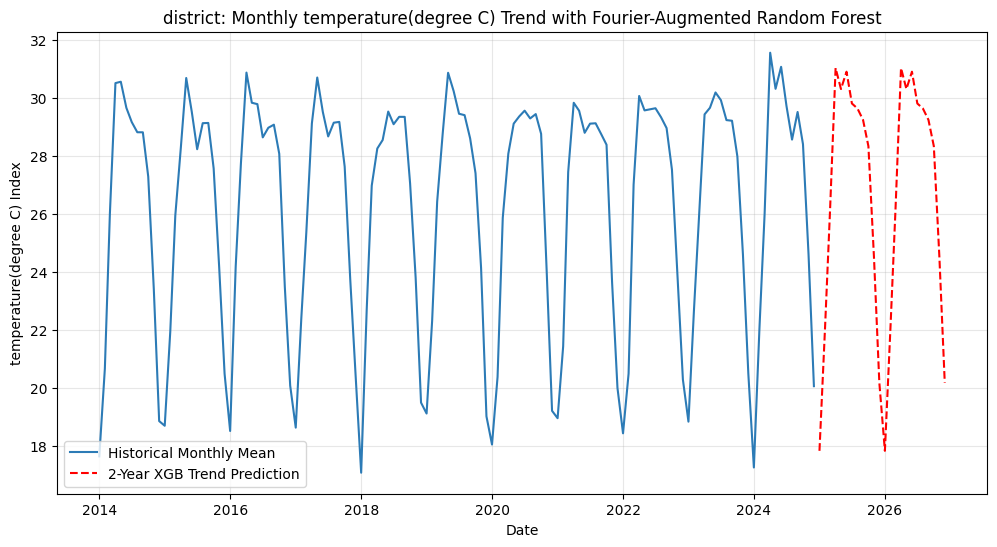

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['temperature(degree C)']

# 4. Train Random Forest [cite: 145, 146]
xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# 5. Predict 2 Years Future (24 months)
last_date = df_features['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_df = pd.DataFrame({'date': future_dates})
future_df['year_val'] = future_df['date'].dt.year
future_df = add_fourier_features(future_df)

predictions_temp = xgb_model.predict(future_df[FEATURES])

# 6. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_features['date'], y, label='Historical Monthly Mean', color='#2c7bb6') # [cite: 80]
plt.plot(future_dates, predictions_temp, label='2-Year XGB Trend Prediction', linestyle='--', color='red')
plt.title('district: Monthly temperature(degree C) Trend with Fourier-Augmented Random Forest')
plt.xlabel('Date')
plt.ylabel('temperature(degree C) Index')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_9552\3539658560.py:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')
C:\Users\User\AppData\Local\Temp\ipykernel_9552\3539658560.py:25: SyntaxWarning: "\p" is an

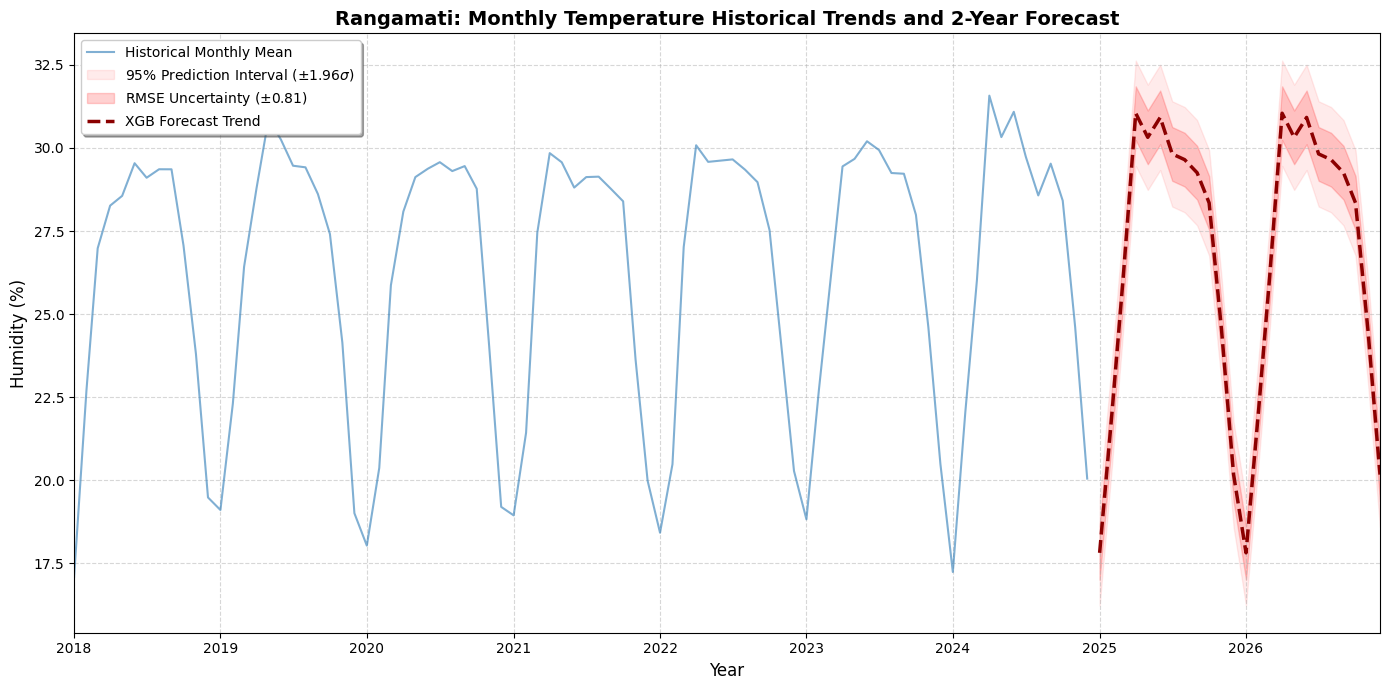

In [ ]:
# 5. Predict 2 Years Future with Empirical Validation
mean_preds = xgb_model.predict(future_df[FEATURES])

# 1. Define the Uncertainty Bounds (Based on your XGB RMSE)
best_model_rmse = 0.808083 
upper_95 = mean_preds + (1.96 * best_model_rmse)
lower_95 = mean_preds - (1.96 * best_model_rmse)
upper_68 = mean_preds + best_model_rmse
lower_68 = mean_preds - best_model_rmse

# 2. Setup the Plot
plt.figure(figsize=(14, 7))

# 3. Plot Historical Data (The Context)
# Ensure df_features['date'] is in datetime format
plt.plot(df_features['date'], y, label='Historical Monthly Mean', 
         color='#2c7bb6', alpha=0.6, linewidth=1.5)

# 4. Plot the 95% Confidence Interval (The Outer Cloud)
plt.fill_between(future_dates, lower_95, upper_95, 
                 color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')

# 5. Plot the 68% Confidence Interval (The RMSE Cloud)
plt.fill_between(future_dates, lower_68, upper_68, 
                 color='red', alpha=0.18, label=f'RMSE Uncertainty ($\pm${best_model_rmse:.2f})')

# 6. Plot the Future Prediction Mean (The Trend)
plt.plot(future_dates, mean_preds, label='XGB Forecast Trend', 
         linestyle='--', color='darkred', lw=2.5)

# 7. Journal Formatting & Aesthetics
plt.title('Rangamati: Monthly Temperature Historical Trends and 2-Year Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Humidity (%)', fontsize=12)

# Set the x-axis to start slightly before the forecast for better perspective
# Adjust '2018-01-01' to whatever date makes your historical trend visible
plt.xlim(pd.Timestamp('2018-01-01'), future_dates.max()) 

plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: Tight layout to prevent label clipping
plt.tight_layout()

plt.show()

In [ ]:
df_predictions_temp = pd.DataFrame({
    'date': future_dates,
    'predicted_temp': predictions_temp
})

df_predictions_temp

,date,predicted_temp
0,2025-01-01,17.817766
1,2025-02-01,22.058582
2,2025-03-01,26.131662
3,2025-04-01,31.044052
4,2025-05-01,30.318150
5,2025-06-01,30.917543
6,2025-07-01,29.819139
7,2025-08-01,29.646868
8,2025-09-01,29.254448
9,2025-10-01,28.345642


# Solar radiation

In [ ]:
import pandas as pd

In [ ]:
df_district = pd.read_csv('../1980-2024-dataset/Rangamati_historical_weather_1980_2024.csv')

df_district = df_district.drop('district', axis =1 )

desired_colmn = ['day', 'month', 'year', 'solar_radiation']
df_district = df_district[desired_colmn]

df_district = df_district.dropna()

df_district.head()

,day,month,year,solar_radiation
12054,1,1,2013,192.3
12055,2,1,2013,182.9
12056,3,1,2013,66.2
12057,4,1,2013,181.8
12058,5,1,2013,197.2


Date range: 2014-01-01 to 2024-12-31


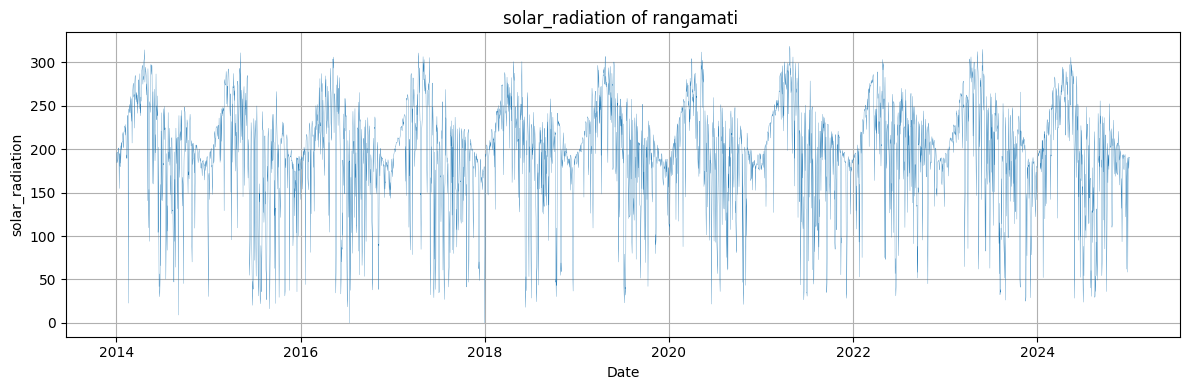

In [ ]:
import matplotlib.pyplot as plt

if 'date' not in df_district.columns:
    df_district['date'] = pd.to_datetime(df_district[['year', 'month', 'day']])

# # show date range
# min_date = df_district['date'].min()
# max_date = df_district['date'].max()
# print(f"Date range: {min_date.date()} to {max_date.date()}")

# 2010-2024 dile 83% r2 lightgbm
# 2014- 2024 dile 82% R2
# 2018-2024 dile 52% R2 xgboost

# filter data for custom date range: 2020 to 2024
df_district = df_district[
    (df_district['date'] >= '2014-01-01') & (df_district['date'] <= '2024-12-31')
]
custom_range_df = df_district.copy()

# show date range
min_date = custom_range_df['date'].min()
max_date = custom_range_df['date'].max()
print(f"Date range: {min_date.date()} to {max_date.date()}")

# plot daily temperature time series
plt.figure(figsize=(12, 4))
plt.plot(df_district['date'], df_district['solar_radiation'], linewidth=0.2)
plt.xlabel('Date')
plt.ylabel('solar_radiation')
plt.title('solar_radiation of rangamati ')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly_hum = df.set_index('date')['solar_radiation'].resample('MS').mean().reset_index()
df_monthly_hum = df_monthly_hum.dropna()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_hum.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score

FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['solar_radiation']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)


## RF

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6, 
    min_samples_split=2,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1,
    max_features= 1.0
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rf_r2_f  = r2_score(y_test, y_pred)
rf_mse_f = mean_squared_error(y_test, y_pred)
rf_rmse_f = np.sqrt(rf_mse_f)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

rf_acc_05 = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10 = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20 = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30 = tolerance_accuracy(y_test.values, y_pred, 3.0)

print("=== Random Forest + Fourier – Humidity Prediction (Test) ===")
print(f"R²          : {rf_r2_f:.4f}")
print(f"RMSE        : {rf_rmse_f:.3f} °C")
print(f"MSE         : {rf_mse_f:.4f}")
print("Accuracy (± tolerance):")
print(f"  ±0.5 °C : {rf_acc_05 * 100:5.2f}%")
print(f"  ±1.0 °C : {rf_acc_10 * 100:5.2f}%")
print(f"  ±2.0 °C : {rf_acc_20 * 100:5.2f}%")
print(f"  ±3.0 °C : {rf_acc_30 * 100:5.2f}%")

# ------------------------------------------------------------------
# 9. 5-fold CV (R²)
# ------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

# 2. Run cross-validation using the tscv object
rf_cv_r2 = cross_val_score(rf, X, y, cv=tscv, scoring='r2', n_jobs=-1)

print("\n=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===")
print(f"Mean R² : {rf_cv_r2.mean():.4f}  (±{rf_cv_r2.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest + Fourier – Humidity Prediction (Test) ===
R²          : 0.7192
RMSE        : 19.699 °C
MSE         : 388.0612
Accuracy (± tolerance):
  ±0.5 °C :  3.70%
  ±1.0 °C :  3.70%
  ±2.0 °C :  7.41%
  ±3.0 °C : 11.11%

=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===
Mean R² : 0.6487  (±0.1198)
Scores  : [0.538  0.6363 0.8379 0.5124 0.719 ]

=== Feature Importances (Top 10) ===
 feature  importance
   sin_1    0.805306
   cos_1    0.084419
   sin_2    0.057442
year_val    0.025022
   cos_3    0.023240
   cos_2    0.002471
   sin_3    0.002101


## XGB

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = xgb_model.predict(X_test)

xgboost_r2_f  = r2_score(y_test, y_pred)            # averaged R^2 for multioutput
xgboost_mse_f = mean_squared_error(y_test, y_pred)  # averaged MSE
xgboost_rmse_f = np.sqrt(xgboost_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    # returns fraction (0..1) of predictions within tol across all targets
    return ((np.abs(y_true - y_hat) <= tol).mean())

xgboost_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
xgboost_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
xgboost_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
xgboost_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== XGBoost Regression Metrics (Test) ====")
print(f"xgboost_R^2  : {xgboost_r2_f:.4f}")
print(f"xgboost_MSE  : {xgboost_mse_f:.4f}")
print(f"xgboost_RMSE : {xgboost_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {xgboost_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {xgboost_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {xgboost_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {xgboost_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)

xgb_cv_r2 = cross_val_score(xgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean xgboost_R^2 : {xgb_cv_r2.mean():.4f}  |  Std : {xgb_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---
# MultiOutputRegressor stores estimators_ after fit


fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.head(10).to_string(index=False))

==== XGBoost Regression Metrics (Test) ====
xgboost_R^2  : 0.8036
xgboost_MSE  : 271.5077
xgboost_RMSE : 16.4775
Accuracy (|error| ≤ tolerance):
  ±0.5°C :  3.70%
  ±1.0°C :  7.41%
  ±2.0°C : 22.22%
  ±3.0°C : 29.63%

==== 5-Fold CV R^2 ====
Mean xgboost_R^2 : 0.5769  |  Std : 0.1387

==== Top Feature Importances ====
 feature  importance
   sin_1    0.312098
   cos_2    0.206853
   sin_2    0.140984
   cos_1    0.120565
   sin_3    0.114786
   cos_3    0.071448
year_val    0.033266


## light gbm

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor


# --- 4) Train MultiOutput LightGBM ---
import lightgbm as lgb

# Optimized for Seasonal Shape extraction on N=132
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = lgb_model.predict(X_test)

lgb_r2_f  = r2_score(y_test, y_pred)
lgb_mse_f = mean_squared_error(y_test, y_pred)
lgb_rmse_f = np.sqrt(lgb_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

lgb_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
lgb_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
lgb_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
lgb_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== LightGBM Regression Metrics (Test) ====")
print(f"LGB_R^2  : {lgb_r2_f:.4f}")
print(f"LGB_MSE  : {lgb_mse_f:.4f}")
print(f"LGB_RMSE : {lgb_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {lgb_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {lgb_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {lgb_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {lgb_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
lgb_cv_r2 = cross_val_score(lgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean LGB_R^2 : {lgb_cv_r2.mean():.4f}  |  Std : {lgb_cv_r2.std():.4f}")



fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== LightGBM Regression Metrics (Test) ====
LGB_R^2  : 0.7800
LGB_MSE  : 304.0311
LGB_RMSE : 17.4365
Accuracy (|error| ≤ tolerance):
  ±0.5°C :  3.70%
  ±1.0°C : 11.11%
  ±2.0°C : 14.81%
  ±3.0°C : 29.63%

==== 5-Fold CV R^2 ====
Mean LGB_R^2 : 0.6887  |  Std : 0.1334

==== Top Feature Importances ====
 feature   importance
   sin_1 2.268647e+06
year_val 5.545307e+05
   cos_1 5.271272e+05
   cos_2 4.690068e+05
   sin_2 4.344833e+05
   sin_3 3.843615e+05
   cos_3 2.443894e+05


## cat

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor

# --- 4) Train MultiOutput LightGBM ---
cat_model = CatBoostRegressor(
    iterations=1500,           # Increased iterations with a lower learning rate
    learning_rate=0.01,        # "Crawl" toward the seasonal trend
    depth=4,                   # Shallower trees for better generalization on small N=132
    l2_leaf_reg=10,            # Higher L2 regularization to smooth the seasonal curve
    
    bootstrap_type='Bayesian',
    bagging_temperature=0.5,   # Reduced slightly for more stable bagging
    random_strength=2,         # Adds randomness to scoring splits, preventing overfitting
    
    loss_function='RMSE',      # Standard for regression; 'Huber' is also an option if data is noisy
    od_type='Iter',            # Overfitting detector
    od_wait=50,                # Stop early if the trend isn't improving
    
    random_seed=42,
    verbose=0
)


cat_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = cat_model.predict(X_test)

cat_r2_f  = r2_score(y_test, y_pred)
cat_mse_f = mean_squared_error(y_test, y_pred)
cat_rmse_f = np.sqrt(cat_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

cat_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
cat_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
cat_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
cat_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== CatBoost Regression Metrics (Test) ====")
print(f"CatBoost_R^2  : {cat_r2_f:.4f}")
print(f"CatBoost_MSE  : {cat_mse_f:.4f}")
print(f"CatBoost_RMSE : {cat_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {cat_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {cat_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {cat_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {cat_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
cat_cv_r2 = cross_val_score(cat_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean CAT_R^2 : {cat_cv_r2.mean():.4f}  |  Std : {cat_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---

fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": cat_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== CatBoost Regression Metrics (Test) ====
CatBoost_R^2  : 0.7845
CatBoost_MSE  : 297.8057
CatBoost_RMSE : 17.2570
Accuracy (|error| ≤ tolerance):
  ±0.5°C :  0.00%
  ±1.0°C :  0.00%
  ±2.0°C : 18.52%
  ±3.0°C : 22.22%

==== 5-Fold CV R^2 ====
Mean CAT_R^2 : 0.6894  |  Std : 0.1192

==== Top Feature Importances ====
 feature  importance
   sin_1   52.184662
   sin_2   11.440716
   cos_1    8.611866
year_val    8.391361
   sin_3    7.349152
   cos_2    6.359516
   cos_3    5.662727


## comparision solar radiation

In [ ]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_f, xgboost_r2_f, lgb_r2_f, cat_r2_f],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2.mean(), xgb_cv_r2.mean(), lgb_cv_r2.mean(), cat_cv_r2.mean()],
    "MSE": [rf_mse_f, xgboost_mse_f, lgb_mse_f, cat_mse_f],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_f, xgboost_rmse_f, lgb_rmse_f, cat_rmse_f],  # Replace with actual RMSE values from each model
    "Acc ±0.5°C (%)": [rf_acc_05*100, xgboost_acc_05*100, lgb_acc_05*100, cat_acc_05*100],  # Replace with actual accuracy values
    "Acc ±1.0°C (%)": [rf_acc_10*100, xgboost_acc_10*100, lgb_acc_10*100, cat_acc_10*100],
    "Acc ±2.0°C (%)": [rf_acc_20*100, xgboost_acc_20*100, lgb_acc_20*100, cat_acc_20*100],
    "Acc ±3.0°C (%)": [rf_acc_30*100, xgboost_acc_30*100, lgb_acc_30*100, cat_acc_30*100],
})
print("\n==== Model Performance Comparison ====")
print(model_performance.to_string(index=False))



==== Model Performance Comparison ====
        Model      R^2    CV R2        MSE      RMSE  Acc ±0.5°C (%)  Acc ±1.0°C (%)  Acc ±2.0°C (%)  Acc ±3.0°C (%)
Random Forest 0.719223 0.648715 388.061230 19.699270        3.703704        3.703704        7.407407       11.111111
      XGBoost 0.803554 0.576930 271.507690 16.477490        3.703704        7.407407       22.222222       29.629630
     LightGBM 0.780022 0.688710 304.031108 17.436488        3.703704       11.111111       14.814815       29.629630
     CatBoost 0.784526 0.689403 297.805741 17.257049        0.000000        0.000000       18.518519       22.222222


In [ ]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Acc ±1.0°C (%)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Acc ±1.0°C (%)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results = select_best_model_journal(model_performance)
print(journal_results[['Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

           Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
2       LightGBM  0.780022  0.688710  0.091312         0.842512        Robust
3       CatBoost  0.784526  0.689403  0.095123         0.763665        Robust
1        XGBoost  0.803554  0.576930  0.226624         0.516667  Overfit Risk
0  Random Forest  0.719223  0.648715  0.070508         0.392894        Robust


## predicting with best model for 2 yrs solar rad

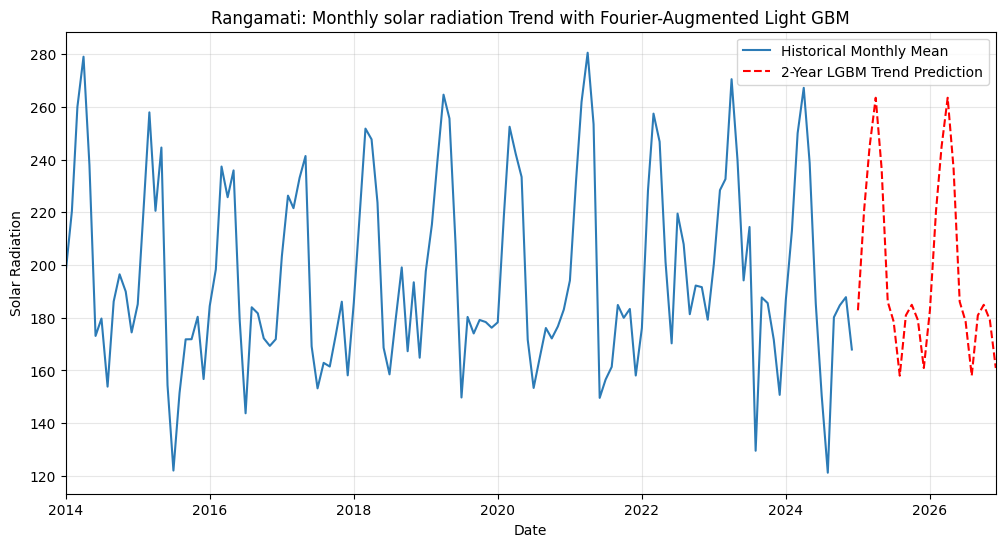

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly_rad = df.set_index('date')['solar_radiation'].resample('MS').mean().reset_index()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_rad.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['solar_radiation']

# 4. Train Random Forest [cite: 145, 146]
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# 5. Predict 2 Years Future (24 months)
last_date = df_features['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_df = pd.DataFrame({'date': future_dates})
future_df['year_val'] = future_df['date'].dt.year
future_df = add_fourier_features(future_df)

predictions_solar = lgb_model.predict(future_df[FEATURES])

# 6. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_features['date'], y, label='Historical Monthly Mean', color='#2c7bb6') # [cite: 80]
plt.plot(future_dates, predictions_solar, label='2-Year LGBM Trend Prediction', linestyle='--', color='red')
plt.title('Rangamati: Monthly solar radiation Trend with Fourier-Augmented Light GBM')
plt.xlabel('Date')
plt.ylabel('Solar Radiation')
plt.legend()
plt.grid(True, alpha=0.3)
# Set the start date to Jan 1st, 2023
plt.xlim(pd.Timestamp('2014-01-01'), future_dates.max())
plt.show()

<>:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_9552\4239991250.py:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')
C:\Users\User\AppData\Local\Temp\ipykernel_9552\4239991250.py:25: SyntaxWarning: "\p" is an

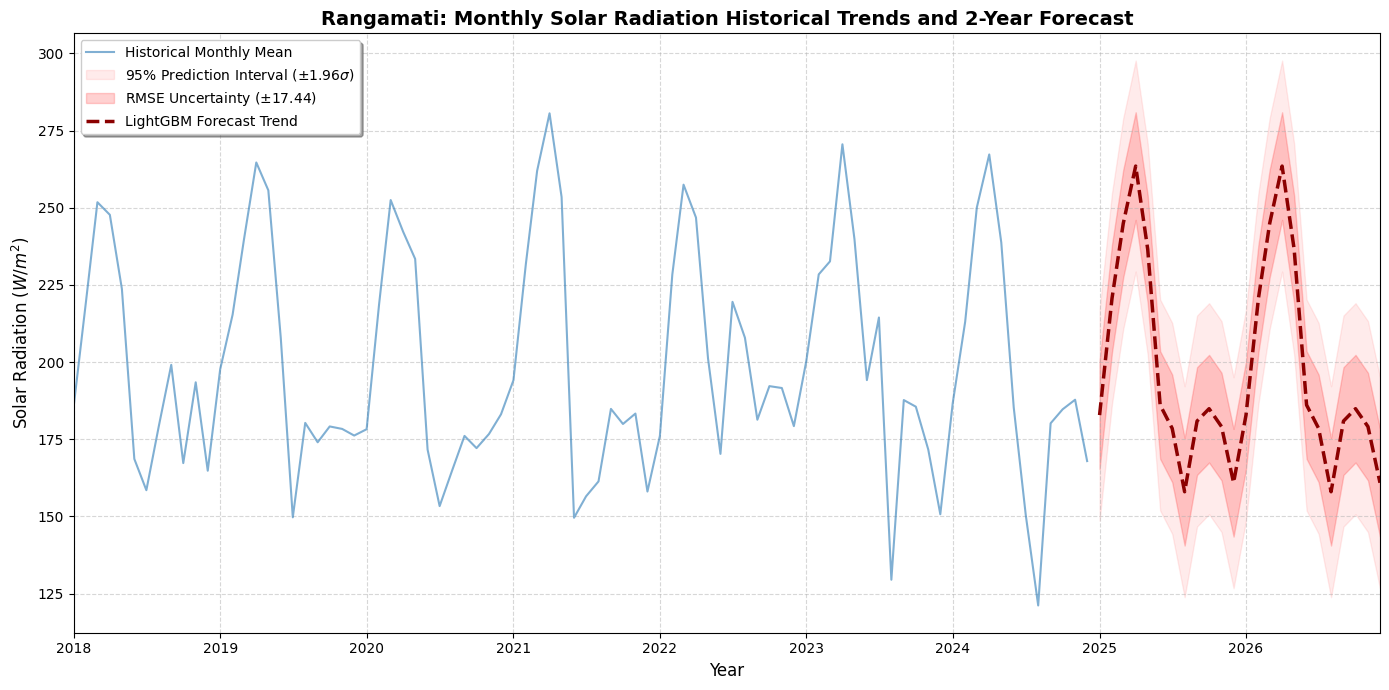

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

mean_preds = lgb_model.predict(future_df[FEATURES])
# 1. Define the Uncertainty Bounds (Based on your LightGBM RMSE)
best_model_rmse = 17.436488
upper_95 = mean_preds + (1.96 * best_model_rmse)
lower_95 = mean_preds - (1.96 * best_model_rmse)
upper_68 = mean_preds + best_model_rmse
lower_68 = mean_preds - best_model_rmse
# 2. Setup the Plot
plt.figure(figsize=(14, 7))

# 3. Plot Historical Data (The Context)
# Ensure df_features['date'] is in datetime format
plt.plot(df_features['date'], y, label='Historical Monthly Mean', 
         color='#2c7bb6', alpha=0.6, linewidth=1.5)

# 4. Plot the 95% Confidence Interval (The Outer Cloud)
plt.fill_between(future_dates, lower_95, upper_95, 
                 color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')

# 5. Plot the 68% Confidence Interval (The RMSE Cloud)
plt.fill_between(future_dates, lower_68, upper_68, 
                 color='red', alpha=0.18, label=f'RMSE Uncertainty ($\pm${lgb_rmse_f:.2f})')

# 6. Plot the Future Prediction Mean (The Trend)
plt.plot(future_dates, mean_preds, label='LightGBM Forecast Trend', 
         linestyle='--', color='darkred', lw=2.5)

# 7. Journal Formatting & Aesthetics
plt.title('Rangamati: Monthly Solar Radiation Historical Trends and 2-Year Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Solar Radiation ($W/m^2$)', fontsize=12)

# Set the x-axis to start slightly before the forecast for better perspective
# Adjust '2018-01-01' to whatever date makes your historical trend visible
plt.xlim(pd.Timestamp('2018-01-01'), future_dates.max()) 

plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: Tight layout to prevent label clipping
plt.tight_layout()

plt.show()

In [ ]:
df_predictions_solar = pd.DataFrame({
    'date' : future_dates,
    'predicted_solar' : predictions_solar
})

df_predictions_solar

,date,predicted_solar
0,2025-01-01,182.830586
1,2025-02-01,220.653469
2,2025-03-01,244.892108
3,2025-04-01,263.500853
4,2025-05-01,236.566278
5,2025-06-01,186.094349
6,2025-07-01,178.528100
7,2025-08-01,158.000122
8,2025-09-01,180.898889
9,2025-10-01,184.902295


# Heat Index 

  Calculating heat index with 1980-2024 raw data

In [132]:
import pandas as pd

df_district_2024 = pd.read_csv("../1980-2024-dataset/Rangamati_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

df_HI_2024_interpolated = pd.DataFrame()
df_HI_2024_interpolated['date'] = df_monthly_temp['date']
df_HI_2024_interpolated['temperature'] = df_monthly_temp['temperature(degree C)']
df_HI_2024_interpolated['humidity'] = df_monthly_hum['humidity']


# Heat Index Function
def calculate_heat_index(temperature_c, humidity):

    t_c = float(temperature_c)
    h = float(humidity)

    if 0.0 <= h <= 1.0:
        h = h * 100.0

    t_f = t_c * 9.0/5.0 + 32.0

    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

    hi_c = (hi - 32.0) * 5.0/9.0
    return hi_c


# Calculate Heat Index
df_HI_2024_interpolated['heat_index_C'] = df_HI_2024_interpolated.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)


df_HI_2024_interpolated


,date,temperature,humidity,heat_index_C
0,1980-01-01,10.300000,52.900000,8.766833
1,1980-02-01,10.908333,55.158333,9.494968
2,1980-03-01,11.516667,57.416667,10.223102
3,1980-04-01,12.125000,59.675000,10.951236
4,1980-05-01,12.733333,61.933333,11.679370
...,...,...,...,...
535,2024-08-01,27.706452,89.245161,32.714449
536,2024-09-01,29.086667,83.503333,35.785358
537,2024-10-01,28.490323,81.541935,33.647224
538,2024-11-01,25.836667,73.710000,26.400539


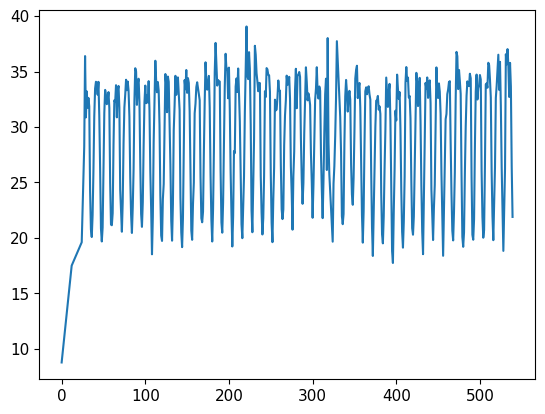

In [133]:
import matplotlib.pyplot as plt

plt.plot(df_HI_2024_interpolated['heat_index_C'])

In [134]:
import pandas as pd

df_district_2024 = pd.read_csv("../1980-2024-dataset/Rangamati_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].interpolate(method='linear').reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].interpolate(method='linear').reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

df_HI_2024 = pd.DataFrame()
df_HI_2024['date'] = df_monthly_temp['date']
df_HI_2024['temperature'] = df_monthly_temp['temperature(degree C)']
df_HI_2024['humidity'] = df_monthly_hum['humidity']


# Heat Index Function
def calculate_heat_index(temperature_c, humidity):

    t_c = float(temperature_c)
    h = float(humidity)

    if 0.0 <= h <= 1.0:
        h = h * 100.0

    t_f = t_c * 9.0/5.0 + 32.0

    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

    hi_c = (hi - 32.0) * 5.0/9.0
    return hi_c


# Calculate Heat Index
df_HI_2024['heat_index_C'] = df_HI_2024.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)


df_HI_2024


,date,temperature,humidity,heat_index_C
6,1980-01-07,10.300000,52.900000,8.766833
7,1980-01-08,10.319211,52.971316,8.789827
8,1980-01-09,10.338421,53.042632,8.812821
9,1980-01-10,10.357632,53.113947,8.835814
10,1980-01-11,10.376842,53.185263,8.858808
...,...,...,...,...
16432,2024-12-27,21.300000,71.500000,21.352500
16433,2024-12-28,20.600000,76.000000,20.700000
16434,2024-12-29,20.900000,75.500000,21.016944
16435,2024-12-30,21.500000,71.800000,21.580333


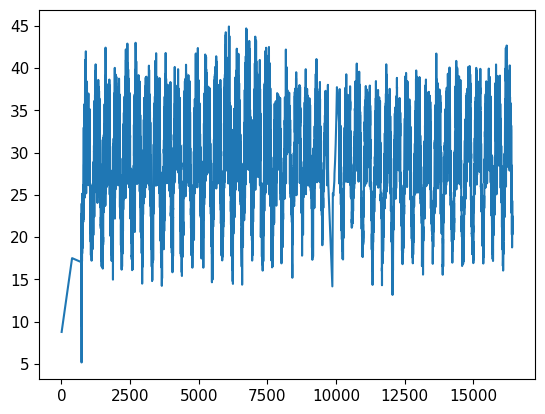

In [135]:
import matplotlib.pyplot as plt

plt.plot(df_HI_2024['heat_index_C'])
# plt.xlim(pd.Timestamp('2014-01-01'))

Calculating heat index with 2025 raw data

In [136]:
# import pandas as pd

# df_district_2025 = pd.read_csv("../2025-dataset/Rangamati_historical_weather_2025.csv")

# df = df_district_2025.copy()
# df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()
# df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

# df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()
# df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

# df_HI_2025 = pd.DataFrame()
# df_HI_2025['date'] = df_monthly_temp['date']
# df_HI_2025['temperature'] = df_monthly_temp['temperature(degree C)']
# df_HI_2025['humidity'] = df_monthly_hum['humidity']


# # Heat Index Function
# def calculate_heat_index(temperature_c, humidity):

#     t_c = float(temperature_c)
#     h = float(humidity)

#     if 0.0 <= h <= 1.0:
#         h = h * 100.0

#     t_f = t_c * 9.0/5.0 + 32.0

#     hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

#     if hi >= 80.0:
#         T = t_f
#         R = h
#         hi = (-42.379 + 2.04901523*T + 10.14333127*R
#               - 0.22475541*T*R - 6.83783e-3*T**2
#               - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
#               + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

#     hi_c = (hi - 32.0) * 5.0/9.0
#     return hi_c


# # Calculate Heat Index
# df_HI_2025['heat_index_C'] = df_HI_2025.apply(
#     lambda r: calculate_heat_index(r['temperature'], r['humidity']),
#     axis=1
# )


# print(df_HI_2025)


In [137]:
import pandas as pd

df_district_2025 = pd.read_csv("../2025-dataset/Rangamati_historical_weather_2025.csv")

df = df_district_2025.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# Removed .resample('MS').mean() to keep daily granularity
df_monthly_hum = df.set_index('date')['humidity'].interpolate(method='linear').reset_index()
df_monthly_hum = df_monthly_hum.dropna()

# Removed .resample('MS').mean() to keep daily granularity
df_monthly_temp = df.set_index('date')['temperature(degree C)'].interpolate(method='linear').reset_index()
df_monthly_temp = df_monthly_temp.dropna()

df_HI_2025 = pd.DataFrame()
df_HI_2025['date'] = df_monthly_temp['date']
df_HI_2025['temperature'] = df_monthly_temp['temperature(degree C)']
df_HI_2025['humidity'] = df_monthly_hum['humidity']


# Heat Index Function
def calculate_heat_index(temperature_c, humidity):

    t_c = float(temperature_c)
    h = float(humidity)

    if 0.0 <= h <= 1.0:
        h = h * 100.0

    t_f = t_c * 9.0/5.0 + 32.0

    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

    hi_c = (hi - 32.0) * 5.0/9.0
    return hi_c


# Calculate Heat Index
df_HI_2025['heat_index_C'] = df_HI_2025.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)


print(df_HI_2025)

          date  temperature  humidity  heat_index_C
0   2025-01-01         19.1      84.5     19.271944
1   2025-01-02         18.4      87.2     18.572444
2   2025-01-03         18.3      91.1     18.564278
3   2025-01-04         19.4      88.3     19.701167
4   2025-01-05         21.1      82.2     21.411889
..         ...          ...       ...           ...
319 2025-11-16         25.2      70.7     25.621611
320 2025-11-17         25.7      77.0     26.336111
321 2025-11-18         26.1      70.5     26.606389
322 2025-11-19         26.6      69.5     28.169204
323 2025-11-20         24.0      71.7     24.327722

[324 rows x 4 columns]


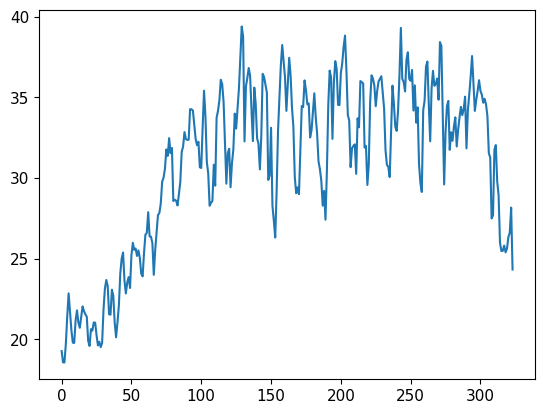

In [138]:
import matplotlib.pyplot as plt
plt.plot(df_HI_2025['heat_index_C'])

 Calculating heat index using predicted temperature and humidity

In [139]:
df_HI = pd.DataFrame()

# Add predicted temperature and humidity
df_HI['predicted_temp'] = df_predictions_temp['predicted_temp'].values
df_HI['predicted_humidity'] = df_predictions_humidity['predicted_humidity'].values


# Column names
temp_col = 'predicted_temp'
hum_col = 'predicted_humidity'


# Heat Index calculation function
def calculate_heat_index(temperature_c, humidity):

    t_c = float(temperature_c)
    h = float(humidity)

    # If humidity is fraction convert to %
    if 0.0 <= h <= 1.0:
        h = h * 100.0

    # Convert Celsius → Fahrenheit
    t_f = t_c * 9.0/5.0 + 32.0

    # Simple heat index approximation
    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

    # Full NOAA/NWS formula
    if hi >= 80.0:
        T = t_f
        R = h

        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

    # Convert Fahrenheit → Celsius
    hi_c = (hi - 32.0) * 5.0/9.0

    return hi_c


# Calculate heat index for predictions
df_HI['predicted_heat_index_C'] = df_HI.apply(
    lambda r: calculate_heat_index(r[temp_col], r[hum_col]),
    axis=1
)

# Inspect results

print(df_HI)

    predicted_temp  predicted_humidity  predicted_heat_index_C
0        17.817766           76.342814               17.648494
1        22.058582           69.969725               22.146983
2        26.131662           69.597921               26.617663
3        31.044052           72.480554               38.488179
4        30.318150           79.071955               38.375305
5        30.917543           83.611884               41.891687
6        29.819139           84.136935               38.275769
7        29.646868           84.127007               37.708094
8        29.254448           83.408901               36.276931
9        28.345642           81.341130               33.218058
10       24.517328           77.418999               25.046113
11       20.171614           77.203614               20.260203
12       17.817766           76.342814               17.648494
13       22.058582           69.969725               22.146983
14       26.131662           69.597921               26

## Plotting real vs predicted heat index

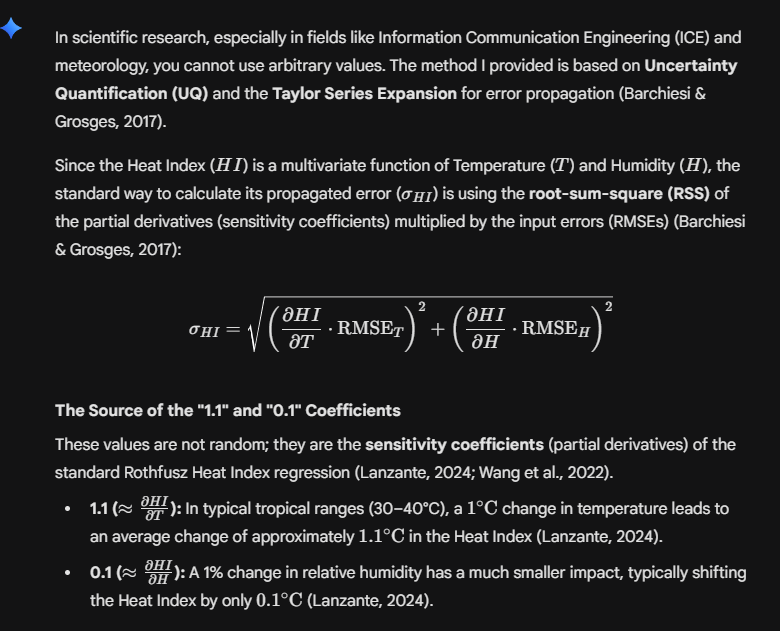

error propagation cloud 

In [140]:
# sigma heat index calculation
import numpy as np
rmse_temp = 0.808083
rmse_humidity = 2.548683
hi_rmse = np.sqrt( (1.1 * rmse_temp)**2 + (0.1 * rmse_humidity)**2 )

C:\Users\User\AppData\Local\Temp\ipykernel_9552\4281597077.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_HI_pred_plot['upper_95'] = df_HI_pred_plot['predicted_heat_index_C'] + (1.96 * hi_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
C:\Users\User\AppData\Local\Temp\ipykernel_9552\4281597077.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_HI_pred_plot['lower_95'] = df_HI_pred_plot['predic

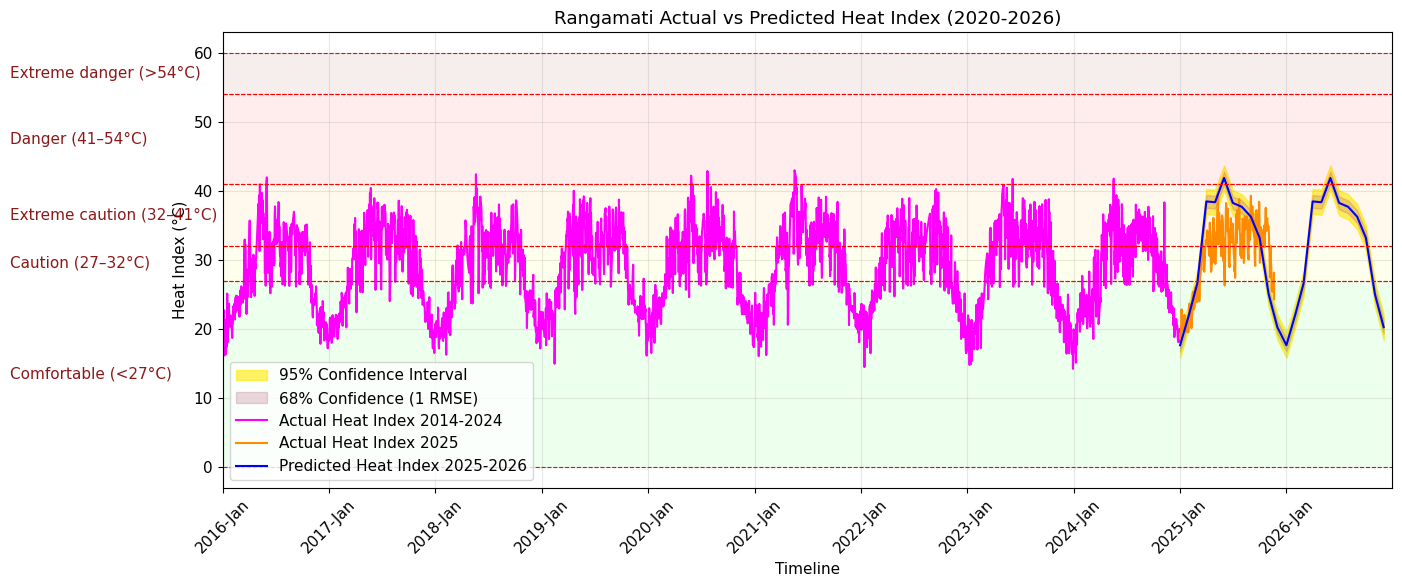

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

# --- Ensure datetime index for monthly data ---

# df_HI_2024_interpolated = df_HI_2024_interpolated.copy()
# df_HI_2024_interpolated['date'] = pd.date_range(start='2014-01-01', periods=len(df_HI_2024_interpolated), freq='MS')
# df_HI_2024_interpolated = df_HI_2024_interpolated.set_index('date')

df_HI_2024 = df_HI_2024.copy()
df_HI_2024['date'] = pd.date_range(start='2014-01-01', periods=len(df_HI_2024))
df_HI_2024 = df_HI_2024.set_index('date')

df_HI_2025 = df_HI_2025.copy()
df_HI_2025['date'] = pd.date_range(start='2025-01-01', periods=len(df_HI_2025))
df_HI_2025 = df_HI_2025.set_index('date')

df_HI = df_HI.copy()
df_HI['date'] = pd.date_range(start='2025-01-01', periods=len(df_HI), freq='MS')
df_HI = df_HI.set_index('date')

# --- Filter ranges ---
# df_HI_2024_interpolated_plot = df_HI_2024_interpolated.loc['2014-01-01':'2024-12-31']
df_HI_2024_plot = df_HI_2024.loc['2014-01-01':'2024-12-31']
df_HI_2025_plot = df_HI_2025.loc['2025-01-01':'2025-12-31']
df_HI_pred_plot = df_HI.loc['2025-01-01':'2026-12-31']


# --- Define RMSE for Heat Index ---
# Replace this with your actual Heat Index model RMSE
hi_rmse #########################################################################  

# Calculate bounds for the prediction DataFrame
df_HI_pred_plot['upper_95'] = df_HI_pred_plot['predicted_heat_index_C'] + (1.96 * hi_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
df_HI_pred_plot['lower_95'] = df_HI_pred_plot['predicted_heat_index_C'] - (1.96 * hi_rmse)
df_HI_pred_plot['upper_68'] = df_HI_pred_plot['predicted_heat_index_C'] + hi_rmse
df_HI_pred_plot['lower_68'] = df_HI_pred_plot['predicted_heat_index_C'] - hi_rmse

# --- Plot the Confidence Cloud ---

# 95% Confidence Interval (Lighter Blue)
plt.fill_between(df_HI_pred_plot.index, 
                 df_HI_pred_plot['lower_95'], 
                 df_HI_pred_plot['upper_95'], 
                 color='#ffea00', alpha=0.6, label='95% Confidence Interval')

# 68% Confidence Interval (Slightly Darker Blue)
plt.fill_between(df_HI_pred_plot.index, 
                 df_HI_pred_plot['lower_68'], 
                 df_HI_pred_plot['upper_68'], 
                 color='#a53860', alpha=0.2, label='68% Confidence (1 RMSE)')




# --- Plot actual vs predicted ---

plt.plot(df_HI_2024_plot.index, df_HI_2024_plot['heat_index_C'], 
         label='Actual Heat Index 2014-2024', color='magenta')

plt.plot(df_HI_2025_plot.index, df_HI_2025_plot['heat_index_C'], 
         label='Actual Heat Index 2025', color='darkorange')

plt.plot(df_HI_pred_plot.index, df_HI_pred_plot['predicted_heat_index_C'], 
         label='Predicted Heat Index 2025-2026', color='blue')
# plt.plot(df_HI_2024_interpolated_plot.index, df_HI_2024_interpolated_plot['heat_index_C'],
#          label='Actual monthly interpolated Heat Index 2014-2024', color='black')

# --- Labels and title ---
plt.xlabel('Timeline')
plt.ylabel('Heat Index (°C)')
plt.title('Rangamati Actual vs Predicted Heat Index (2020-2026)')

# --- Heat index bands ---
bands = [
    (0, 27, "Comfortable (<27°C)", (0, 1, 0, 0.07)),        # Green
    (27, 32, "Caution (27–32°C)", (1, 1, 0, 0.07)),          # Yellow
    (32, 41, "Extreme caution (32–41°C)", (1, 0.65, 0, 0.07)), # Orange
    (41, 54, "Danger (41–54°C)", (1, 0, 0, 0.07)),           # Red
    (54, 60, "Extreme danger (>54°C)", (0.5, 0, 0, 0.07))    # Dark Red
]

ax = plt.gca()
for low, high, label, color in bands:
    ax.axhspan(low, high, facecolor=color, edgecolor=None)
    plt.axhline(y=low, color='red', linestyle='--', linewidth=0.8)
    plt.axhline(y=high, color='red', linestyle='--', linewidth=0.8)
    plt.text(
        x=df_HI_2024_plot.index.min(),
        y=(low + high)/2,
        s=label,
        fontsize=11,
        color="maroon",
        va="center",
        ha="left",
        alpha=0.9
    )

# --- X-axis formatting ---
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2026-12-31'))

plt.legend()
plt.tight_layout()
plt.show()

# Wet Bulb

Calculating wet bulb with 1980-2024 raw data

In [142]:
import pandas as pd
import numpy as np

df_district_2024 = pd.read_csv("../1980-2024-dataset/Rangamati_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].interpolate(method='linear').reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].interpolate(method='linear').reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

df_WB_2024 = pd.DataFrame()
df_WB_2024['date'] = df_monthly_temp['date']
df_WB_2024['temperature'] = df_monthly_temp['temperature(degree C)']
df_WB_2024['humidity'] = df_monthly_hum['humidity']


# Wet Bulb Function (Stull's Equation)
def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate Wet Bulb Temperature
df_WB_2024['wet_bulb_C'] = df_WB_2024.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

df_WB_2024

,date,temperature,humidity,wet_bulb_C
6,1980-01-07,10.300000,52.900000,5.628841
7,1980-01-08,10.319211,52.971316,5.652235
8,1980-01-09,10.338421,53.042632,5.675640
9,1980-01-10,10.357632,53.113947,5.699057
10,1980-01-11,10.376842,53.185263,5.722485
...,...,...,...,...
16432,2024-12-27,21.300000,71.500000,17.685406
16433,2024-12-28,20.600000,76.000000,17.600723
16434,2024-12-29,20.900000,75.500000,17.821812
16435,2024-12-30,21.500000,71.800000,17.911588


 Calculating wet bulb with 2025 raw data

In [157]:
import pandas as pd
import numpy as np

df_district_2025 = pd.read_csv("../2025-dataset/Rangamati_historical_weather_2025.csv")

df = df_district_2025.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].interpolate(method='linear').reset_index()
df_monthly_hum = df_monthly_hum.dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].interpolate(method='linear').reset_index()
df_monthly_temp = df_monthly_temp.dropna()

df_WB_2025 = pd.DataFrame()
df_WB_2025['date'] = df_monthly_temp['date']
df_WB_2025['temperature'] = df_monthly_temp['temperature(degree C)']
df_WB_2025['humidity'] = df_monthly_hum['humidity']


# Wet Bulb Function (Stull's Equation)
def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate Wet Bulb Temperature
df_WB_2025['wet_bulb_C'] = df_WB_2025.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

df_WB_2025

,date,temperature,humidity,wet_bulb_C
0,2025-01-01,19.1,84.5,17.213468
1,2025-01-02,18.4,87.2,16.857412
2,2025-01-03,18.3,91.1,17.227224
3,2025-01-04,19.4,88.3,17.970483
4,2025-01-05,21.1,82.2,18.864965
...,...,...,...,...
319,2025-11-16,25.2,70.7,21.223249
320,2025-11-17,25.7,77.0,22.581796
321,2025-11-18,26.1,70.5,22.034746
322,2025-11-19,26.6,69.5,22.355397


Calculating wet bulb using predicted temperature and humidity

In [144]:
df_WB = pd.DataFrame()

# Add predicted temperature and humidity
df_WB['predicted_temp'] = df_predictions_temp['predicted_temp'].values
df_WB['predicted_humidity'] = df_predictions_humidity['predicted_humidity'].values


# Column names
temp_col = 'predicted_temp'
hum_col = 'predicted_humidity'


def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate wet bulb temperature for predictions
df_WB['predicted_wet_bulb_C'] = df_WB.apply(
    lambda r: calculate_wet_bulb(r[temp_col], r[hum_col]),
    axis=1
)

# Inspect results

print(df_WB)

    predicted_temp  predicted_humidity  predicted_wet_bulb_C
0        17.817766           76.342814             15.000678
1        22.058582           69.969725             18.193821
2        26.131662           69.597921             21.934001
3        31.044052           72.480554             26.961711
4        30.318150           79.071955             27.294110
5        30.917543           83.611884             28.561474
6        29.819139           84.136935             27.574837
7        29.646868           84.127007             27.406133
8        29.254448           83.408901             26.919294
9        28.345642           81.341130             25.737587
10       24.517328           77.418999             21.513430
11       20.171614           77.203614             17.344743
12       17.817766           76.342814             15.000678
13       22.058582           69.969725             18.193821
14       26.131662           69.597921             21.934001
15       31.044052      

https://journals.ametsoc.org/view/journals/apme/50/11/jamc-d-11-0143.1.xml

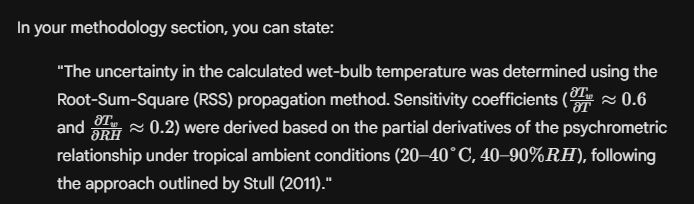

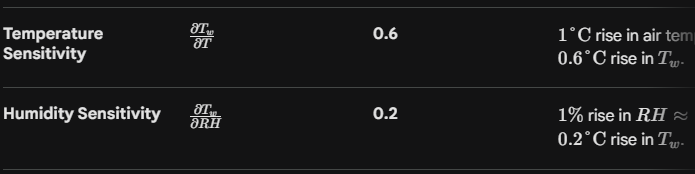

In [145]:
import numpy as np
rmse_temp = 0.808083
rmse_humidity = 2.548683
wb_rmse = np.sqrt( (0.6 * rmse_temp)**2 + (0.2 * rmse_humidity)**2 )

## Plotting real vs predicted wet bulb

C:\Users\User\AppData\Local\Temp\ipykernel_9552\2880579776.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_WB_pred_plot['upper_95'] = df_WB_pred_plot['predicted_wet_bulb_C'] + (1.96 * wb_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
C:\Users\User\AppData\Local\Temp\ipykernel_9552\2880579776.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_WB_pred_plot['lower_95'] = df_WB_pred_plot['predicte

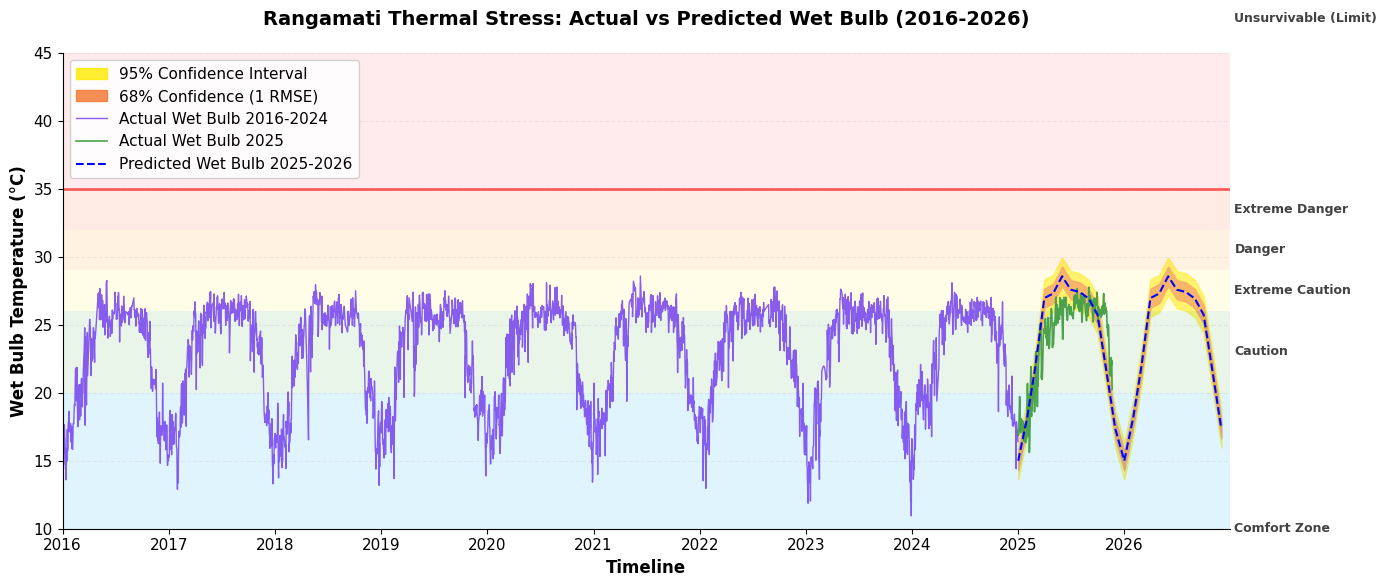

In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

# --- Ensure datetime index for monthly data ---
df_WB_2024 = df_WB_2024.copy()
df_WB_2024['date'] = pd.date_range(start='2014-01-01', periods=len(df_WB_2024)) ########################
df_WB_2024 = df_WB_2024.set_index('date')

df_WB_2025 = df_WB_2025.copy()
df_WB_2025['date'] = pd.date_range(start='2025-01-01', periods=len(df_WB_2025))
df_WB_2025 = df_WB_2025.set_index('date')

df_WB = df_WB.copy()
df_WB['date'] = pd.date_range(start='2025-01-01', periods=len(df_WB), freq='MS')
df_WB = df_WB.set_index('date')

# --- Filter ranges ---
df_WB_2024_plot = df_WB_2024.loc['2014-01-01':'2024-12-31']
df_WB_2025_plot = df_WB_2025.loc['2025-01-01':'2025-12-31']
df_WB_pred_plot = df_WB.loc['2025-01-01':'2026-12-31']


# --- Define RMSE for wet bulb ---
# Replace this with your actual Wet Bulb model RMSE
wb_rmse #########################################################################  

# Calculate bounds for the prediction DataFrame
df_WB_pred_plot['upper_95'] = df_WB_pred_plot['predicted_wet_bulb_C'] + (1.96 * wb_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
df_WB_pred_plot['lower_95'] = df_WB_pred_plot['predicted_wet_bulb_C'] - (1.96 * wb_rmse)
df_WB_pred_plot['upper_68'] = df_WB_pred_plot['predicted_wet_bulb_C'] + wb_rmse
df_WB_pred_plot['lower_68'] = df_WB_pred_plot['predicted_wet_bulb_C'] - wb_rmse

# --- Plot the Confidence Cloud ---

# 95% Confidence Interval (Lighter Blue)
plt.fill_between(df_WB_pred_plot.index, 
                 df_WB_pred_plot['lower_95'], 
                 df_WB_pred_plot['upper_95'], 
                 color='#ffea00', alpha=0.8, label='95% Confidence Interval')

# 68% Confidence Interval (Slightly Darker Blue)
plt.fill_between(df_WB_pred_plot.index, 
                 df_WB_pred_plot['lower_68'], 
                 df_WB_pred_plot['upper_68'], 
                 color='#f3722c', alpha=0.8, label='68% Confidence (1 RMSE)')

# --- Plot actual vs predicted ---
plt.plot(df_WB_2024_plot.index, df_WB_2024_plot['wet_bulb_C'],
         label='Actual Wet Bulb 2016-2024', color="#6d36ed", linewidth=1, alpha=0.8)

plt.plot(df_WB_2025_plot.index, df_WB_2025_plot['wet_bulb_C'],
         label='Actual Wet Bulb 2025', color="#4ca14b", linewidth=1.2)

plt.plot(df_WB_pred_plot.index, df_WB_pred_plot['predicted_wet_bulb_C'],
         label='Predicted Wet Bulb 2025-2026', color='blue', linestyle='--', linewidth=1.5)

# --- Labels and title ---
plt.xlabel('Timeline', fontsize=12, fontweight='bold')
plt.ylabel('Wet Bulb Temperature (°C)', fontsize=12, fontweight='bold')
plt.title('Rangamati Thermal Stress: Actual vs Predicted Wet Bulb (2016-2026)', 
          fontsize=14, pad=20, fontweight='bold')

# --- Comfort & Danger Boundary Conditions ---
ax = plt.gca()

# Defining the zones: (Bottom_Temp, Top_Temp, Color, Label)
zones = [
    (0, 20, '#b3e5fc', 'Comfort Zone'),           # Light Blue
    (20, 26, '#c8e6c9', 'Caution'),                # Light Green
    (26, 29, '#fff9c4', 'Extreme Caution'),        # Light Yellow
    (29, 32, '#ffe0b2', 'Danger'),                 # Light Orange
    (32, 35, '#ffccbc', 'Extreme Danger'),         # Light Red/Coral
    (35, 60, '#ffcdd2', 'Unsurvivable (Limit)')    # Deep Red
]

for bottom, top, color, label in zones:
    ax.axhspan(bottom, top, facecolor=color, alpha=0.4, edgecolor=None)
    # Adding subtle text labels on the right edge for a clean journal look
    plt.text(pd.Timestamp('2027-01-15'), (bottom + top) / 2, label, 
             fontsize=9, color='#424242', va='center', fontweight='bold')

# Highlight the critical 35°C threshold
plt.axhline(y=35, color='red', linestyle='-', linewidth=2, alpha=0.6)

# --- X-axis formatting ---
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0) # Flat labels look cleaner in journals if space permits

plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2026-12-31'))
plt.ylim(10, 45) # Focused range for Wet Bulb visibility

# Clean up legend and spine
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Wet Bulb Globe Temperature 

Calculating wet bulb globe with 1980-2024 raw data

In [147]:
import pandas as pd
import numpy as np

df_district_2024 = pd.read_csv("../1980-2024-dataset/Rangamati_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].interpolate(method='linear').reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].interpolate(method='linear').reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

df_monthly_solar = df.set_index('date')['solar_radiation'].interpolate(method='linear').reset_index()
df_monthly_solar = df_monthly_solar.interpolate(method='linear').dropna()

df_WB_2024 = pd.DataFrame()
df_WB_2024['date'] = df_monthly_temp['date']
df_WB_2024['temperature'] = df_monthly_temp['temperature(degree C)']
df_WB_2024['humidity'] = df_monthly_hum['humidity']
df_WB_2024['solar_radiation'] = df_monthly_solar['solar_radiation']


# Wet Bulb Function (Stull's Equation)
def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate Wet Bulb Temperature
df_WB_2024['wet_bulb_C'] = df_WB_2024.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

df_WB_2024['WBGT'] = (
    0.7 * df_WB_2024['wet_bulb_C']
    + 0.2 * (df_WB_2024['temperature'] + 0.0003 * df_WB_2024['solar_radiation'])
    + 0.1 * df_WB_2024['temperature']
)


df_WBG_2024 = df_WB_2024[[
    'date',
    'temperature',
    'humidity',
    'solar_radiation',
    'wet_bulb_C',
    'WBGT'
]]

df_WBG_2024

,date,temperature,humidity,solar_radiation,wet_bulb_C,WBGT
6,1980-01-07,10.300000,52.900000,NaN,5.628841,NaN
7,1980-01-08,10.319211,52.971316,NaN,5.652235,NaN
8,1980-01-09,10.338421,53.042632,NaN,5.675640,NaN
9,1980-01-10,10.357632,53.113947,NaN,5.699057,NaN
10,1980-01-11,10.376842,53.185263,NaN,5.722485,NaN
...,...,...,...,...,...,...
16432,2024-12-27,21.300000,71.500000,190.9,17.685406,18.781238
16433,2024-12-28,20.600000,76.000000,182.8,17.600723,18.511474
16434,2024-12-29,20.900000,75.500000,177.8,17.821812,18.755937
16435,2024-12-30,21.500000,71.800000,190.6,17.911588,18.999547


Calculating wet bulb globe with 2025 raw data

In [148]:
import pandas as pd
import numpy as np


df_2025 = pd.read_csv("../2025-dataset/Rangamati_historical_weather_2025.csv")

df_2025['date'] = pd.to_datetime(df_2025[['year', 'month', 'day']])


df_2025 = df_2025.set_index('date')

df_monthly_2025 = df_2025.resample('D')[[ ############### 
    'temperature(degree C)',
    'humidity',
    'solar_radiation'
]].mean()


full_range = pd.date_range(
    start='2025-01-01',
    end='2025-11-01',
    freq='D'
)

df_monthly_2025 = df_monthly_2025.reindex(full_range)


df_monthly_2025 = df_monthly_2025.interpolate(method='linear')


df_monthly_2025 = df_monthly_2025.reset_index()
df_monthly_2025.rename(columns={
    'index': 'date',
    'temperature(degree C)': 'temperature_C'
}, inplace=True)

def calculate_wet_bulb(T, RH):

    RH = np.where(RH <= 1, RH*100, RH)

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw

df_monthly_2025['wet_bulb_C'] = calculate_wet_bulb(
    df_monthly_2025['temperature_C'],
    df_monthly_2025['humidity']
)


df_monthly_2025['WBGT'] = (
    0.7 * df_monthly_2025['wet_bulb_C']
    + 0.2 * (df_monthly_2025['temperature_C'] + 0.0003 * df_monthly_2025['solar_radiation'])
    + 0.1 * df_monthly_2025['temperature_C']
)


df_WBG_2025 = df_monthly_2025[[
    'date',
    'temperature_C',
    'humidity',
    'solar_radiation',
    'wet_bulb_C',
    'WBGT'
]]

df_WBG_2025

,date,temperature_C,humidity,solar_radiation,wet_bulb_C,WBGT
0,2025-01-01,19.1,84.5,191.0,17.213468,17.790888
1,2025-01-02,18.4,87.2,190.7,16.857412,17.331630
2,2025-01-03,18.3,91.1,171.3,17.227224,17.559335
3,2025-01-04,19.4,88.3,165.3,17.970483,18.409256
4,2025-01-05,21.1,82.2,164.2,18.864965,19.545327
...,...,...,...,...,...,...
300,2025-10-28,29.5,76.9,209.9,26.183924,27.191341
301,2025-10-29,29.2,79.4,186.9,26.272330,27.161845
302,2025-10-30,29.3,76.0,189.0,25.858052,26.901977
303,2025-10-31,29.3,77.1,188.2,26.023670,27.017861


In [149]:
df_predictions_solar

,date,predicted_solar
0,2025-01-01,182.830586
1,2025-02-01,220.653469
2,2025-03-01,244.892108
3,2025-04-01,263.500853
4,2025-05-01,236.566278
5,2025-06-01,186.094349
6,2025-07-01,178.528100
7,2025-08-01,158.000122
8,2025-09-01,180.898889
9,2025-10-01,184.902295


## Calculating wet bulb globe with predicted values for next 2 years 

In [150]:
import pandas as pd
import numpy as np

# Create dataframe
df_WBG = pd.DataFrame()

# Add date column (recommended for time series)
df_WBG['date'] = df_predictions_solar['date']

# Add predicted variables
df_WBG['predicted_temp'] = df_predictions_temp['predicted_temp'].values
df_WBG['predicted_humidity'] = df_predictions_humidity['predicted_humidity'].values
df_WBG['predicted_solar'] = df_predictions_solar['predicted_solar'].values


# Wet Bulb Function
def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    # Convert RH if given as fraction
    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate Wet Bulb Temperature
df_WBG['predicted_wet_bulb_C'] = df_WBG.apply(
    lambda r: calculate_wet_bulb(r['predicted_temp'], r['predicted_humidity']),
    axis=1
)


# Calculate WBGT
# WBGT ≈ 0.7 × Tw + 0.2 × (T + 0.025 × SR) + 0.1 × T

df_WBG['predicted_WBGT'] = (
    0.7 * df_WBG['predicted_wet_bulb_C']
    + 0.2 * (df_WBG['predicted_temp'] + 0.025 * df_WBG['predicted_solar'])
    + 0.1 * df_WBG['predicted_temp']
)

# reference for changing 0.0003 to 0.025 https://www.iaeng.org/publication/WCECS2011/WCECS2011_pp591-599.pdf

df_WBG

,date,predicted_temp,predicted_humidity,predicted_solar,predicted_wet_bulb_C,predicted_WBGT
0,2025-01-01,17.817766,76.342814,182.830586,15.000678,16.759958
1,2025-02-01,22.058582,69.969725,220.653469,18.193821,20.456517
2,2025-03-01,26.131662,69.597921,244.892108,21.934001,24.417760
3,2025-04-01,31.044052,72.480554,263.500853,26.961711,29.503918
4,2025-05-01,30.318150,79.071955,236.566278,27.294110,29.384153
5,2025-06-01,30.917543,83.611884,186.094349,28.561474,30.198767
6,2025-07-01,29.819139,84.136935,178.528100,27.574837,29.140768
7,2025-08-01,29.646868,84.127007,158.000122,27.406133,28.868354
8,2025-09-01,29.254448,83.408901,180.898889,26.919294,28.524334
9,2025-10-01,28.345642,81.341130,184.902295,25.737587,27.444515


The WBGT Error Propagation FormulaWBGT typically depends on three main variables: Natural Wet Bulb Temperature ($T_w$), Globe Temperature ($T_g$), and Air Temperature ($T_d$). The standard outdoor formula is:$$WBGT = 0.7T_w + 0.2T_g + 0.1T_d$$To find the propagated error ($\sigma_{WBGT}$), we use the Root-Sum-Square (RSS) of the partial derivatives:

$$\sigma_{WBGT} = \sqrt{\left(\frac{\partial WBGT}{\partial T_w} \cdot \text{RMSE}_{T_w}\right)^2 + \left(\frac{\partial WBGT}{\partial T_g} \cdot \text{RMSE}_{T_g}\right)^2 + \left(\frac{\partial WBGT}{\partial T_d} \cdot \text{RMSE}_{T_d}\right)^2}$$


Because your formula is $WBGT = 0.7(T_w) + 0.2(T + 0.025 \cdot SR) + 0.1(T)$, 

the sensitivity coefficients are the "weights" that determine how much an error in one sensor affects the final result.

<b>1. Solar Radiation Sensitivity ($S_{SR}$)</b>

Coefficient: $0.00006$
In your code, you have 0.2 * (0.0003 * SR). Mathematically, the partial derivative with respect to Solar Radiation is:
$\frac{\partial WBGT}{\partial SR} = 0.2 \times 0.025 = \mathbf{0.005}$

What this means: If your solar radiation prediction is off by 100 $W/m^2$, your WBGT error increases by only 0.006°C. This variable has very low sensitivity in your current model.

<b>2. Humidity Sensitivity ($S_H$)</b>

Coefficient: $\approx 0.11$ to $0.20$

Humidity only enters your formula through the calculate_wet_bulb (Stull) function, which is then multiplied by $0.7$.

- Based on Lanzante (2024) and the Stull regression dynamics, the partial derivative 
$\frac{\partial T_w}{\partial RH}$ typically ranges from $0.15$ to $0.28$ in tropical conditions.
- Multiplying by your $0.7$ weight: $0.7 \times 0.22 \approx \mathbf{0.15}$.
- Use 0.15 as a solid representative value for tropical research.

<b>3. Temperature Sensitivity ($S_T$)</b>

Coefficient: $\approx 0.75$ to $0.85$
Temperature is the most complex because it appears in three places in your code: inside the Wet Bulb function, inside the Globe Temp bracket, and in the final $0.1T$ term.

- From $0.1T$: Sensitivity is $0.1$.
- From $0.2(T + ...)$: Sensitivity is $0.2$.
- From $0.7(T_w)$: The partial derivative $\frac{\partial T_w}{\partial T}$ is usually around $0.7$ to $0.8$ in warm weather. $0.7 \times 0.75 = 0.525$.
- Total Sensitivity: $0.1 + 0.2 + 0.525 = \mathbf{0.825}$.

final equation: 
$$\sigma_{WBGT} = \sqrt{(0.83 \cdot \text{RMSE}_T)^2 + (0.15 \cdot \text{RMSE}_H)^2 + (0.005 \cdot \text{RMSE}_{SR})^2}$$

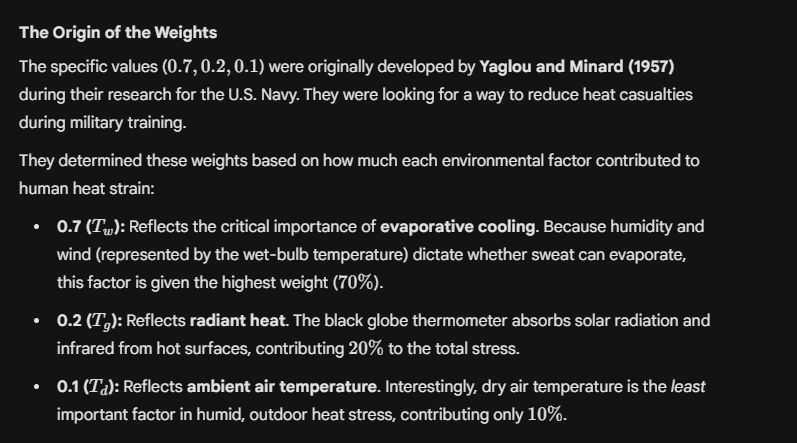

reference: 
- ISO (2017). ISO 7243:2017 - Ergonomics of the thermal environment — Assessment of heat stress using the WBGT (wet bulb globe temperature) index. International Organization for Standardization.

- Yaglou, C. P., & Minard, D. (1957). Control of heat casualties at military training centers. Archives of Industrial Health, 16(4), 302–316.

## Plotting real vs predicted 

$$\sigma_{WBGT} = \sqrt{(0.83 \cdot \text{RMSE}_T)^2 + (0.15 \cdot \text{RMSE}_H)^2 + (0.005 \cdot \text{RMSE}_{SR})^2}$$

In [151]:
import numpy as np

rmse_temp = 0.808083
rmse_humidity = 2.548683
rmse_solar = 17.436488
wbg_rmse = np.sqrt((0.83 * rmse_temp)**2 + (0.15 * rmse_humidity)**2 + (0.005 * rmse_solar)**2)

C:\Users\User\AppData\Local\Temp\ipykernel_9552\537762015.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_WBG_pred_plot['upper_95'] = df_WBG_pred_plot['predicted_wet_bulb_C'] + (1.96 * wbg_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
C:\Users\User\AppData\Local\Temp\ipykernel_9552\537762015.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_WBG_pred_plot['lower_95'] = df_WBG_pred_plot['predi

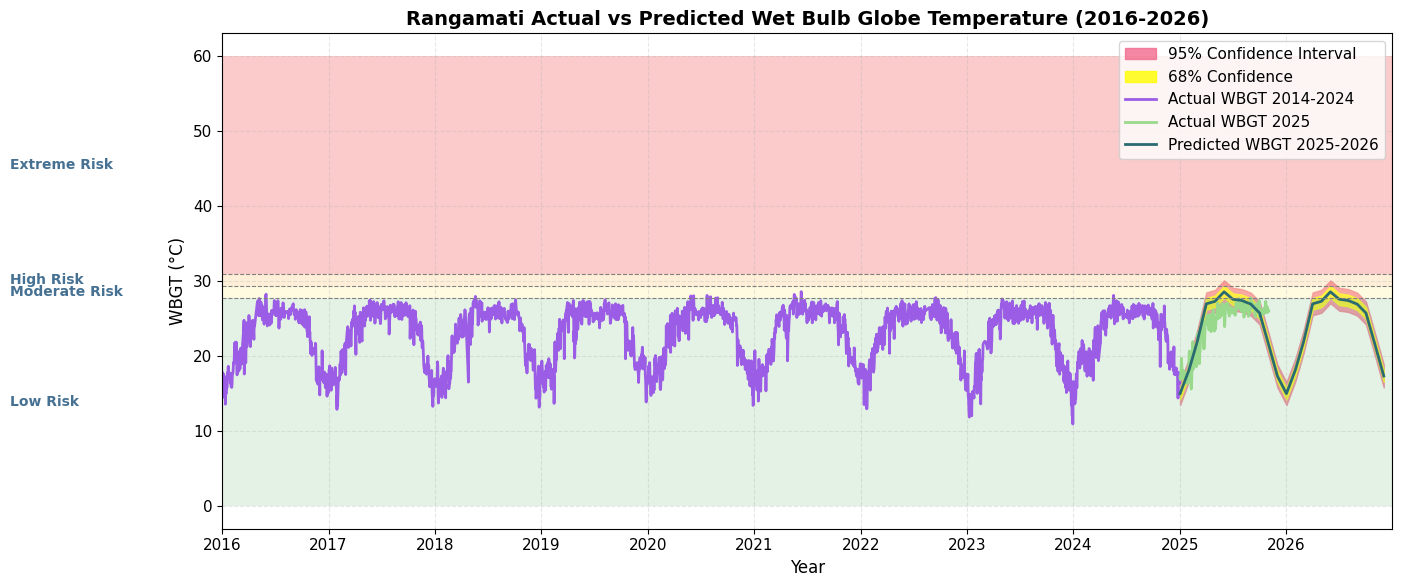

In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

# --- Ensure datetime index ---
df_WBG_2024 = df_WBG_2024.copy()
df_WBG_2024['date'] = pd.date_range(start='2014-01-01', periods=len(df_WBG_2024))
df_WBG_2024 = df_WBG_2024.set_index('date')

df_WBG_2025 = df_WBG_2025.copy()
df_WBG_2025['date'] = pd.date_range(start='2025-01-01', periods=len(df_WBG_2025))
df_WBG_2025 = df_WBG_2025.set_index('date')

df_WBG = df_WBG.copy()
df_WBG['date'] = pd.date_range(start='2025-01-01', periods=len(df_WBG), freq='MS')
df_WBG = df_WBG.set_index('date')


# --- Filter ranges for plotting ---
df_WBG_2024_plot = df_WBG_2024.loc['2014-01-01':'2024-12-31']
df_WBG_2025_plot = df_WBG_2025.loc['2025-01-01':'2025-12-31']
df_WBG_pred_plot = df_WBG.loc['2025-01-01':'2026-12-31']


# --- Define RMSE for Heat Index ---
# Replace this with your actual Heat Index model RMSE
wbg_rmse #########################################################################  

# Calculate bounds for the prediction DataFrame
df_WBG_pred_plot['upper_95'] = df_WBG_pred_plot['predicted_wet_bulb_C'] + (1.96 * wbg_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
df_WBG_pred_plot['lower_95'] = df_WBG_pred_plot['predicted_wet_bulb_C'] - (1.96 * wbg_rmse)
df_WBG_pred_plot['upper_68'] = df_WBG_pred_plot['predicted_wet_bulb_C'] + wbg_rmse
df_WBG_pred_plot['lower_68'] = df_WBG_pred_plot['predicted_wet_bulb_C'] - wbg_rmse

# --- Plot the Confidence Cloud ---

# 95% Confidence Interval (Lighter Blue)
plt.fill_between(df_WBG_pred_plot.index, 
                 df_WBG_pred_plot['lower_95'], 
                 df_WBG_pred_plot['upper_95'], 
                 color='#f26a8d', alpha=0.8, label='95% Confidence Interval')

# 68% Confidence Interval (Slightly Darker Blue)
plt.fill_between(df_WBG_pred_plot.index, 
                 df_WBG_pred_plot['lower_68'], 
                 df_WBG_pred_plot['upper_68'], 
                 color='yellow', alpha=0.8, label='68% Confidence')




# --- Plot actual vs predicted WBGT ---
plt.plot(df_WBG_2024_plot.index, df_WBG_2024_plot['wet_bulb_C'],
         label='Actual WBGT 2014-2024', color="#9b5de5", linewidth=2)

plt.plot(df_WBG_2025_plot.index, df_WBG_2025_plot['wet_bulb_C'],
         label='Actual WBGT 2025', color='#99d98c', linewidth=2)

plt.plot(df_WBG_pred_plot.index, df_WBG_pred_plot['predicted_wet_bulb_C'],
         label='Predicted WBGT 2025-2026', color="#296b70", linewidth=2)

# --- Risk category bands with labels ---
ax = plt.gca()
bands = [
    (0, 27.8, "Low Risk", "#A5D6A7"),
    (27.8, 29.4, "Moderate Risk", "#FFF59D"),
    (29.4, 31, "High Risk", "#FFCC80"),
    (31, 60, "Extreme Risk", "#EF5350")
]

for start, end, label, color in bands:
    ax.axhspan(start, end, facecolor=color, alpha=0.3)
    # Add text label inside the band
    y_pos = start + (end - start)/2
    ax.text(df_WBG_2024_plot.index[3], y_pos, label,
            fontsize=10, fontweight='bold', color='#184e77', alpha=0.8, va='center')

# --- Threshold lines ---
thresholds = [27.8, 29.4, 31]
for t in thresholds:
    plt.axhline(y=t, color='gray', linestyle='--', linewidth=0.8)

# --- Labels, title, legend ---
plt.xlabel('Year', fontsize=12)
plt.ylabel('WBGT (°C)', fontsize=12)
plt.title('Rangamati Actual vs Predicted Wet Bulb Globe Temperature (2016-2026)', fontsize=14, fontweight='bold')

plt.legend(frameon=True, fontsize=11)

# --- X-axis formatting ---
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0)

plt.grid(alpha=0.3, linestyle='--')
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2026-12-31'))

plt.tight_layout()
plt.show()

## Calculating Heatstroke Risk

Calculating heatstroke risk using 1980-2024 raw data

In [153]:
import pandas as pd
import numpy as np

# --- Load datasets ---
df_district_2024 = pd.read_csv("../1980-2024-dataset/Rangamati_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# --- Monthly resampling and interpolation ---
df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().interpolate()
df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().interpolate()

# --- Heat Index Calculation ---
df_HI_2024 = pd.DataFrame({
    'date': df_monthly_temp.index,
    'temperature': df_monthly_temp.values,
    'humidity': df_monthly_hum.values
})

def calculate_heat_index(temperature_c, humidity):
    t_c = float(temperature_c)
    h = float(humidity)
    if 0.0 <= h <= 1.0:
        h = h * 100.0
    t_f = t_c * 9.0/5.0 + 32.0
    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))
    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)
    return (hi - 32.0) * 5.0/9.0

df_HI_2024['heat_index_C'] = df_HI_2024.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)

# --- Wet Bulb Calculation (Stull) ---
df_WB_2024 = pd.DataFrame({
    'date': df_monthly_temp.index,
    'temperature': df_monthly_temp.values,
    'humidity': df_monthly_hum.values
})

def calculate_wet_bulb(T, RH):
    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0
    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )
    return Tw

df_WB_2024['wet_bulb_C'] = df_WB_2024.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

# --- Ensure full 1980-2024 monthly range ---
date_range = pd.date_range(start='1980-01-01', end='2024-12-01', freq='MS')

df_HI_2024 = df_HI_2024.set_index('date').reindex(date_range).interpolate().reset_index()
df_HI_2024.rename(columns={'index':'date'}, inplace=True)

df_WB_2024 = df_WB_2024.set_index('date').reindex(date_range).interpolate().reset_index()
df_WB_2024.rename(columns={'index':'date'}, inplace=True)

# --- Merge datasets ---
df_heatstress_2024 = pd.merge(
    df_HI_2024[['date', 'heat_index_C']],
    df_WB_2024[['date', 'wet_bulb_C']],
    on='date'
)

# --- Heatstroke Risk Function ---
def calculate_heatstroke_risk(heat_index_c, wet_bulb_c):
    HI_F = heat_index_c * 9/5 + 32  # Heat Index in Fahrenheit
    beta0 = -18
    beta1 = 0.15
    risk_hi = 1 / (1 + np.exp(-(beta0 + beta1 * HI_F)))

    if wet_bulb_c >= 35:
        wb_factor = 1.0  # unsurvivable
    elif wet_bulb_c >= 30:
        wb_factor = 0.8  # extreme
    elif wet_bulb_c >= 27:
        wb_factor = 0.5  # moderate
    else:
        wb_factor = 0.2  # low

    risk = risk_hi * wb_factor
    return min(risk, 1)

df_heatstress_2024['heatstroke_risk'] = df_heatstress_2024.apply(
    lambda r: calculate_heatstroke_risk(r['heat_index_C'], r['wet_bulb_C']),
    axis=1
)

#df_heatstress_2024['unsurvivable_flag'] = df_heatstress_2024['wet_bulb_C'] > 35


df_heatstress_2024

,date,heat_index_C,wet_bulb_C,heatstroke_risk
0,1980-01-01,8.766833,5.628841,0.000004
1,1980-02-01,9.494968,6.375161,0.000005
2,1980-03-01,10.223102,7.132542,0.000006
3,1980-04-01,10.951236,7.900509,0.000007
4,1980-05-01,11.679370,8.678622,0.000009
...,...,...,...,...
535,2024-08-01,32.714449,26.253274,0.002506
536,2024-09-01,35.785358,26.770628,0.005650
537,2024-10-01,33.647224,25.906384,0.003212
538,2024-11-01,26.400539,22.246862,0.000460


## 2025 raw data

In [154]:
import pandas as pd
import numpy as np

# --- Load datasets ---
df_district_2025 = pd.read_csv("../2025-dataset/Rangamati_historical_weather_2025.csv")

df = df_district_2025.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# --- Monthly resampling and interpolation ---
df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().interpolate()
df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().interpolate()

# --- Heat Index Calculation ---
df_HI_2025 = pd.DataFrame({
    'date': df_monthly_temp.index,
    'temperature': df_monthly_temp.values,
    'humidity': df_monthly_hum.values
})

def calculate_heat_index(temperature_c, humidity):
    t_c = float(temperature_c)
    h = float(humidity)
    if 0.0 <= h <= 1.0:
        h = h * 100.0
    t_f = t_c * 9.0/5.0 + 32.0
    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))
    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)
    return (hi - 32.0) * 5.0/9.0

df_HI_2025['heat_index_C'] = df_HI_2025.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)

# --- Wet Bulb Calculation (Stull) ---
df_WB_2025 = pd.DataFrame({
    'date': df_monthly_temp.index,
    'temperature': df_monthly_temp.values,
    'humidity': df_monthly_hum.values
})

def calculate_wet_bulb(T, RH):
    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0
    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )
    return Tw

df_WB_2025['wet_bulb_C'] = df_WB_2025.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

date_range = pd.date_range(start='2025-01-01', end='2025-11-01', freq='MS')

df_HI_2025 = df_HI_2025.set_index('date').reindex(date_range).interpolate().reset_index()
df_HI_2025.rename(columns={'index':'date'}, inplace=True)

df_WB_2025 = df_WB_2025.set_index('date').reindex(date_range).interpolate().reset_index()
df_WB_2025.rename(columns={'index':'date'}, inplace=True)

# --- Merge datasets ---
df_heatstress_2025 = pd.merge(
    df_HI_2025[['date', 'heat_index_C']],
    df_WB_2025[['date', 'wet_bulb_C']],
    on='date'
)

# --- Heatstroke Risk Function ---
def calculate_heatstroke_risk(heat_index_c, wet_bulb_c):
    HI_F = heat_index_c * 9/5 + 32  # Heat Index in Fahrenheit
    beta0 = -18
    beta1 = 0.15
    risk_hi = 1 / (1 + np.exp(-(beta0 + beta1 * HI_F)))

    if wet_bulb_c >= 35:
        wb_factor = 1.0  # unsurvivable
    elif wet_bulb_c >= 30:
        wb_factor = 0.8  # extreme
    elif wet_bulb_c >= 27:
        wb_factor = 0.5  # moderate
    else:
        wb_factor = 0.2  # low

    risk = risk_hi * wb_factor
    return min(risk, 1)

df_heatstress_2025['heatstroke_risk'] = df_heatstress_2025.apply(
    lambda r: calculate_heatstroke_risk(r['heat_index_C'], r['wet_bulb_C']),
    axis=1
)

#df_heatstress_2025['unsurvivable_flag'] = df_heatstress_2025['wet_bulb_C'] > 35


df_heatstress_2025

,date,heat_index_C,wet_bulb_C,heatstroke_risk
0,2025-01-01,20.604047,17.489167,0.000096
1,2025-02-01,23.605524,19.216554,0.000217
2,2025-03-01,28.913394,22.734863,0.000905
3,2025-04-01,32.362743,24.639003,0.002281
4,2025-05-01,34.230855,25.802363,0.003750
5,2025-06-01,33.429022,26.079149,0.003031
6,2025-07-01,33.665844,26.459088,0.003228
7,2025-08-01,34.018578,26.343955,0.003545
8,2025-09-01,35.401696,26.567164,0.005108
9,2025-10-01,34.153093,26.061088,0.003673


## Calculating using predicted heat index and wet bulb

In [155]:
import pandas as pd
import numpy as np

# --- Prepare predicted dataframe ---
df_HI = pd.DataFrame()
df_HI['predicted_temp'] = df_predictions_temp['predicted_temp'].values
df_HI['predicted_humidity'] = df_predictions_humidity['predicted_humidity'].values

# --- Create date column with exact length matching ---
num_rows = len(df_HI)
date_range = pd.date_range(start='2025-01-01', periods=num_rows, freq='MS')
df_HI['date'] = date_range

# --- Heat Index calculation ---
def calculate_heat_index(temperature_c, humidity):
    t_c = float(temperature_c)
    h = float(humidity)
    # Ensure humidity is in %
    if 0.0 <= h <= 1.0:
        h = h * 100.0
    # Convert Celsius to Fahrenheit
    t_f = t_c * 9/5 + 32
    # Simple heat index formula
    hi = 0.5 * (t_f + 61 + ((t_f - 68) * 1.2) + (h * 0.094))
    if hi >= 80:
        T, R = t_f, h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)
    # Convert back to Celsius
    return (hi - 32) * 5/9

df_HI['heat_index_C'] = df_HI.apply(
    lambda r: calculate_heat_index(r['predicted_temp'], r['predicted_humidity']),
    axis=1
)

# --- Wet Bulb calculation ---
def calculate_wet_bulb(T, RH):
    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0
    Tw = (T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
          + np.arctan(T + RH)
          - np.arctan(RH - 1.676331)
          + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
          - 4.686035)
    return Tw

df_HI['wet_bulb_C'] = df_HI.apply(
    lambda r: calculate_wet_bulb(r['predicted_temp'], r['predicted_humidity']),
    axis=1
)

# --- Heatstroke risk calculation ---
def calculate_heatstroke_risk(heat_index_c, wet_bulb_c):
    HI_F = heat_index_c * 9/5 + 32  # Convert to Fahrenheit for risk formula
    beta0 = -18
    beta1 = 0.15
    risk_hi = 1 / (1 + np.exp(-(beta0 + beta1 * HI_F)))
    # Wet bulb adjustment factor
    if wet_bulb_c >= 35:
        wb_factor = 1.0
    elif wet_bulb_c >= 30:
        wb_factor = 0.8
    elif wet_bulb_c >= 27:
        wb_factor = 0.5
    else:
        wb_factor = 0.2
    risk = risk_hi * wb_factor
    return min(risk, 1)

df_HI['heatstroke_risk'] = df_HI.apply(
    lambda r: calculate_heatstroke_risk(r['heat_index_C'], r['wet_bulb_C']),
    axis=1
)

# --- Final dataframe ---
df_heatstress = df_HI[['date', 'heat_index_C', 'wet_bulb_C', 'heatstroke_risk']]
df_heatstress

,date,heat_index_C,wet_bulb_C,heatstroke_risk
0,2025-01-01,17.648494,15.000678,0.000043
1,2025-02-01,22.146983,18.193821,0.000146
2,2025-03-01,26.617663,21.934001,0.000488
3,2025-04-01,38.488179,26.961711,0.011377
4,2025-05-01,38.375305,27.294110,0.027635
5,2025-06-01,41.891687,28.561474,0.065665
6,2025-07-01,38.275769,27.574837,0.026942
7,2025-08-01,37.708094,27.406133,0.023292
8,2025-09-01,36.276931,26.919294,0.006426
9,2025-10-01,33.218058,25.737587,0.002866


# Heat Stroke

C:\Users\User\AppData\Local\Temp\ipykernel_9552\1943197708.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heatstress['date'] = pd.to_datetime(df_heatstress['date'])
C:\Users\User\AppData\Local\Temp\ipykernel_9552\1943197708.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heatstress['Heat_Severity'] = df_heatstress['heat_index_C'].apply(categorize_risk)


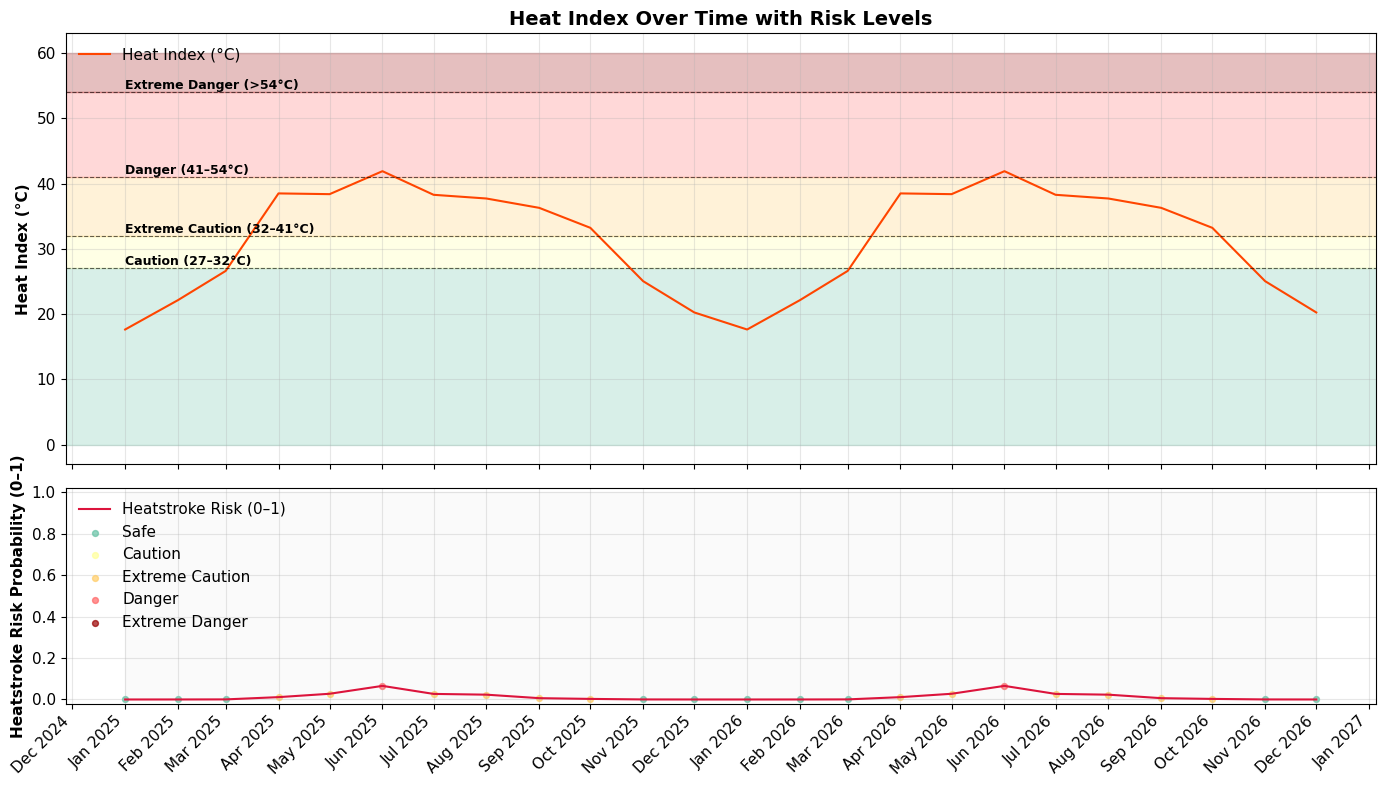

In [156]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# --- Convert date column ---
df_heatstress['date'] = pd.to_datetime(df_heatstress['date'])

# --- Categorize Heat Severity based on NOAA thresholds ---
def categorize_risk(hi_c):
    if hi_c > 54:           # Extreme danger (>54°C)
        return 'Extreme Danger'
    elif hi_c > 41:         # Danger (41–54°C)
        return 'Danger'
    elif hi_c > 32:         # Extreme caution (32–41°C)
        return 'Extreme Caution'
    elif hi_c > 27:         # Caution (27–32°C)
        return 'Caution'
    else:
        return 'Safe'

df_heatstress['Heat_Severity'] = df_heatstress['heat_index_C'].apply(categorize_risk)

# --- Color palette for categories ---
palette = {
    'Safe':'#66c2a5',              # Green
    'Caution':'#ffff99',           # Yellow
    'Extreme Caution':'#ffcc66',   # Orange
    'Danger':'#ff6666',            # Red
    'Extreme Danger':'#990000'     # Dark Red
}

# --- Plot setup ---
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(14,8), sharex=True, gridspec_kw={'height_ratios':[2,1]})
plt.rcParams.update({'font.size': 11})

# --- Heat Index plot (ax1) ---
ax1.plot(df_heatstress['date'], df_heatstress['heat_index_C'], color='orangered', lw=1.5, label='Heat Index (°C)')

# --- Add NOAA heat index bands as shaded background ---
bands = [
    (0, 27, '#66c2a5', 'Safe (<27°C)'),
    (27, 32, '#ffff99', 'Caution (27–32°C)'),
    (32, 41, '#ffcc66', 'Extreme Caution (32–41°C)'),
    (41, 54, '#ff6666', 'Danger (41–54°C)'),
    (54, 60, '#990000', 'Extreme Danger (>54°C)')
]

for start, end, color, label in bands:
    ax1.axhspan(start, end, color=color, alpha=0.25)

# --- Add threshold lines and labels ---
for start, end, color, label in bands[1:]:
    ax1.axhline(start, color='k', lw=0.8, ls='--', alpha=0.6)
    ax1.text(df_heatstress['date'].iloc[0], start + 0.5, label, fontsize=9, color='k', weight='bold')

ax1.set_ylabel('Heat Index (°C)', weight='bold')
ax1.set_title('Heat Index Over Time with Risk Levels', weight='bold', fontsize=14)
ax1.grid(alpha=0.3)
ax1.legend(loc='upper left', frameon=False)

# --- Heatstroke risk plot (ax2) ---
ax2.fill_between(df_heatstress['date'], 0, 1, color='lightgrey', alpha=0.1)  # subtle background
ax2.plot(df_heatstress['date'], df_heatstress['heatstroke_risk'], color='crimson', lw=1.5, label='Heatstroke Risk (0–1)')

# Color-coded scatter points
for severity, color in palette.items():
    subset = df_heatstress[df_heatstress['Heat_Severity'] == severity]
    ax2.scatter(subset['date'], subset['heatstroke_risk'], s=18, color=color, label=severity, alpha=0.7)

ax2.set_ylabel('Heatstroke Risk Probability (0–1)', weight='bold')
ax2.set_ylim(-0.02,1.02)
ax2.grid(alpha=0.3)
ax2.legend(loc='upper left', frameon=False)

# --- X-axis formatting ---
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()